In [5]:
def load_data(filename: str):
  # Conll file is stored as (token, tag) pairs, one per line
  # Extracting data from conll files
  with open(filename, 'r', encoding='UTF-8') as file:
    lines = [line[:-1].split() for line in file] # Skipping last line as it will be a blank space
  samples, start = [], 0
  for end, parts in enumerate(lines):
      if not parts:
          sample = [(token, tag)
                      for token, tag in lines[start:end]]
          samples.append(sample)
          start = end + 1
  if start < end:
    samples.append(lines[start:end])
  return samples

train_samples = load_data('/content/wnut 16.txt.conll')
test_samples = load_data('/content/wnut 16test.txt.conll')
samples = train_samples + test_samples
schema = ['_'] + sorted({tag for sentence in samples
                             for _, tag in sentence}) # '_' is used to indicate a null (blank) token.

## 1. Data Ingestion & Overview
### Step 1.2: Dataset Information (Print lengths, tweet counts)

In [6]:
# Calculate and print the number of training and testing samples
num_train_samples = len(train_samples)
num_test_samples = len(test_samples)
print(f"Number of training samples (sentences): {num_train_samples}")
print(f"Number of testing samples (sentences): {num_test_samples}")

# Calculate and print the total number of sentences
total_sentences = len(samples)
print(f"Total number of sentences in the dataset: {total_sentences}")

# Calculate the total number of tokens (words) across all samples
total_tokens = sum(len(sentence) for sentence in samples)
print(f"Total number of tokens (words) in the dataset: {total_tokens}")

# Calculate and print the number of unique tags in the schema
num_unique_tags = len(schema)
print(f"Number of unique tags: {num_unique_tags}")


Number of training samples (sentences): 2394
Number of testing samples (sentences): 3850
Total number of sentences in the dataset: 6244
Total number of tokens (words) in the dataset: 108375
Number of unique tags: 22


<Axes: xlabel='keys'>

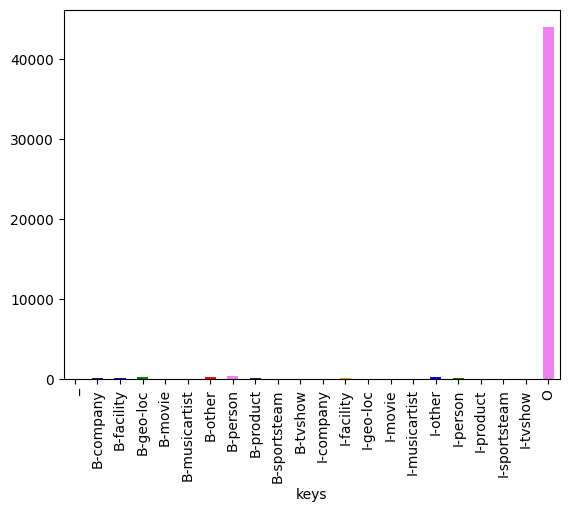

In [7]:
import seaborn as sns
import pandas as pd

colors = ['violet', 'indigo', 'blue', 'green', 'yellow', 'orange', 'red']
counts = {}

# Calculateing the number of data points having a given label
for tag in schema:
  counts[tag] = 0
  for sample in train_samples:
    for label in sample:
      if label[1] == tag:
        counts[tag]+=1

counts_df = pd.DataFrame({'keys': list(counts.keys()), 'values': list(counts.values())})
counts_df.plot.bar(x='keys', y='values', legend=False, color=colors)

### Step 2.2: Sequence Length Distribution Analysis (Determine Max Padding Length)

Minimum sentence length: 1
Maximum sentence length: 39
Average sentence length: 17.36
Median sentence length: 17.0


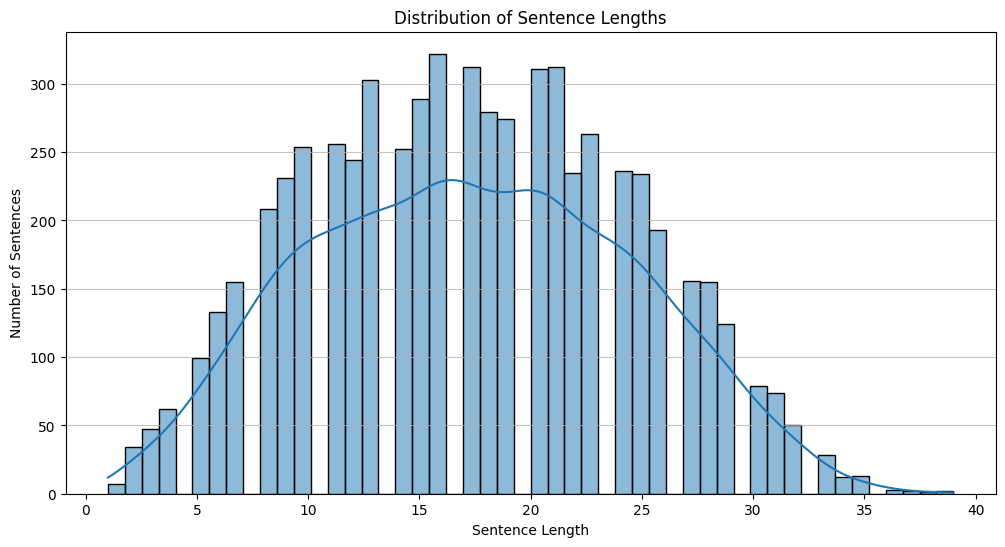

Suggested max padding length (95th percentile): 29


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate sentence lengths for all samples
sentence_lengths = [len(sentence) for sentence in samples]

# Print some basic statistics about sentence lengths
print(f"Minimum sentence length: {min(sentence_lengths)}")
print(f"Maximum sentence length: {max(sentence_lengths)}")
print(f"Average sentence length: {np.mean(sentence_lengths):.2f}")
print(f"Median sentence length: {np.median(sentence_lengths)}")

# Plotting the distribution of sentence lengths
plt.figure(figsize=(12, 6))
sns.histplot(sentence_lengths, bins=50, kde=True)
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Number of Sentences')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Determine a suitable max_padding_length using percentiles
# For example, using the 95th percentile to cover most sentences
max_padding_length = int(np.percentile(sentence_lengths, 95))
print(f"Suggested max padding length (95th percentile): {max_padding_length}")

# Store the chosen max padding length for later use
MAX_PAD_LEN = max_padding_length


## 3. Text Preprocessing & Tokenization
### Step 3.1: Create Vocabulary (word2idx with <PAD>, <UNK>)

In [9]:
# Flatten the list of all words from all sentences
all_words = [word for sentence in samples for word, _ in sentence]

# Get unique words and sort them to ensure consistent vocabulary
unique_words = sorted(list(set(all_words)))

# Define special tokens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Create word2idx and idx2word mappings
# Add special tokens at the beginning of the vocabulary
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for i, word in enumerate(unique_words):
    word2idx[word] = i + 2 # Start indexing from 2 after special tokens

idx2word = {idx: word for word, idx in word2idx.items()}

# Print vocabulary statistics
vocabulary_size = len(word2idx)
print(f"Vocabulary size (including {PAD_TOKEN} and {UNK_TOKEN}): {vocabulary_size}")
print(f"First 10 words in word2idx: {list(word2idx.items())[:10]}")
print(f"Last 10 words in word2idx: {list(word2idx.items())[-10:]}")


Vocabulary size (including <PAD> and <UNK>): 25384
First 10 words in word2idx: [('<PAD>', 0), ('<UNK>', 1), ('!', 2), ('!!', 3), ('!!!', 4), ('!!!!', 5), ('!!!!!', 6), ('!!!!!!', 7), ('!!!!!!!', 8), ('!!!!!!!!', 9)]
Last 10 words in word2idx: [('“@allinwithchris', 25374), ('“@cnnbrk', 25375), ('“@nbcchicago', 25376), ('“@piersmorgan', 25377), ('”', 25378), ('”so', 25379), ('”ummm', 25380), ('…', 25381), ('■CNN速報(米版)：CNN', 25382), ('【Slash', 25383)]


### Step 3.2: Create Tag Mapping (tag2idx, idx2tag)

In [10]:
# The 'schema' variable already contains all unique tags sorted, including '_'
# We can use this directly to create tag2idx and idx2tag mappings

# Create tag2idx mapping
tag2idx = {tag: i for i, tag in enumerate(schema)}

# Create idx2tag mapping
idx2tag = {i: tag for tag, i in tag2idx.items()}

# Print tag mapping statistics
num_tags = len(tag2idx)
print(f"Number of unique tags: {num_tags}")
print(f"Tag to index mapping (first 10): {list(tag2idx.items())[:10]}")
print(f"Index to tag mapping (first 10): {list(idx2tag.items())[:10]}")


Number of unique tags: 22
Tag to index mapping (first 10): [('_', 0), ('B-company', 1), ('B-facility', 2), ('B-geo-loc', 3), ('B-movie', 4), ('B-musicartist', 5), ('B-other', 6), ('B-person', 7), ('B-product', 8), ('B-sportsteam', 9)]
Index to tag mapping (first 10): [(0, '_'), (1, 'B-company'), (2, 'B-facility'), (3, 'B-geo-loc'), (4, 'B-movie'), (5, 'B-musicartist'), (6, 'B-other'), (7, 'B-person'), (8, 'B-product'), (9, 'B-sportsteam')]


### Step 3.3: Convert Sentences to Indices

In [11]:
# Function to convert a list of (word, tag) tuples to (word_idx, tag_idx) tuples
def convert_to_indices(samples, word_to_idx_map, tag_to_idx_map):
    indexed_samples = []
    for sentence in samples:
        indexed_sentence = []
        for word, tag in sentence:
            # Use UNK_TOKEN index if word is not in vocabulary
            word_idx = word_to_idx_map.get(word, word_to_idx_map[UNK_TOKEN])
            tag_idx = tag_to_idx_map[tag]
            indexed_sentence.append((word_idx, tag_idx))
        indexed_samples.append(indexed_sentence)
    return indexed_samples

# Convert training and testing samples to indices
indexed_train_samples = convert_to_indices(train_samples, word2idx, tag2idx)
indexed_test_samples = convert_to_indices(test_samples, word2idx, tag2idx)

print("Converted training samples to indices.")
print(f"First 5 indexed training samples: {indexed_train_samples[:5]}")

print("\nConverted testing samples to indices.")
print(f"First 5 indexed testing samples: {indexed_test_samples[:5]}")


Converted training samples to indices.
First 5 indexed training samples: [[(4687, 21), (6250, 21), (24291, 21), (25060, 21), (14869, 21), (14437, 21), (16254, 21), (15250, 21), (13024, 21), (24547, 21), (21407, 21), (2145, 21)], [(10667, 21), (20625, 21), (14762, 21), (17549, 21), (24394, 21), (8985, 3), (2199, 21), (9808, 21), (23975, 21), (21886, 21), (24394, 21), (14869, 21), (14667, 21), (8294, 2), (25143, 12), (2150, 21), (15237, 21), (20637, 21), (17191, 21), (24394, 21), (14869, 21), (17549, 21), (2199, 21), (13382, 21), (24394, 21), (23850, 21), (22431, 21), (24274, 21), (21814, 21), (8294, 2), (14063, 12), (24526, 21), (2199, 21)], [(2042, 21), (7340, 4), (8156, 14), (2042, 21), (12175, 21), (24394, 21), (13689, 3), (22008, 21), (9900, 21), (2546, 21), (17942, 21)], [(5835, 21), (22299, 21), (2150, 21), (15237, 21), (16920, 21), (21394, 21), (16836, 21), (23703, 21), (20471, 21), (24274, 21), (17070, 21), (24270, 21), (20609, 21), (17472, 21), (20471, 21), (24280, 21), (15964,

### Step 3.4: Padding Sequences (Standardize tensor shapes)

In [12]:
import tensorflow as tf

# Function to pad sequences to MAX_PAD_LEN
def pad_sequences(indexed_samples, max_len, pad_word_idx, pad_tag_idx):
    padded_word_sequences = []
    padded_tag_sequences = []

    for sentence in indexed_samples:
        word_indices = [word_idx for word_idx, _ in sentence]
        tag_indices = [tag_idx for _, tag_idx in sentence]

        # Pad or truncate word sequences
        if len(word_indices) > max_len:
            padded_word_sequences.append(word_indices[:max_len])
        else:
            padded_word_sequences.append(word_indices + [pad_word_idx] * (max_len - len(word_indices)))

        # Pad or truncate tag sequences
        if len(tag_indices) > max_len:
            padded_tag_sequences.append(tag_indices[:max_len])
        else:
            padded_tag_sequences.append(tag_indices + [pad_tag_idx] * (max_len - len(tag_indices)))

    # Convert to TensorFlow tensors
    return tf.constant(padded_word_sequences), tf.constant(padded_tag_sequences)

# Get padding indices
pad_word_idx = word2idx[PAD_TOKEN]
pad_tag_idx = tag2idx['_'] # Using the index for the null tag '_'

# Pad training and testing data
X_train, y_train = pad_sequences(indexed_train_samples, MAX_PAD_LEN, pad_word_idx, pad_tag_idx)
X_test, y_test = pad_sequences(indexed_test_samples, MAX_PAD_LEN, pad_word_idx, pad_tag_idx)

print("Padding complete.")
print(f"Shape of X_train (word indices): {X_train.shape}")
print(f"Shape of y_train (tag indices): {y_train.shape}")
print(f"Shape of X_test (word indices): {X_test.shape}")
print(f"Shape of y_test (tag indices): {y_test.shape}")

print("\nFirst padded training sentence (words):\n", X_train[0].numpy())
print("First padded training sentence (tags):\n", y_train[0].numpy())


Padding complete.
Shape of X_train (word indices): (2394, 29)
Shape of y_train (tag indices): (2394, 29)
Shape of X_test (word indices): (3850, 29)
Shape of y_test (tag indices): (3850, 29)

First padded training sentence (words):
 [ 4687  6250 24291 25060 14869 14437 16254 15250 13024 24547 21407  2145
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0]
First padded training sentence (tags):
 [21 21 21 21 21 21 21 21 21 21 21 21  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0]


### Step 3.5: One-Hot Encoding (Or using sparse target conversions)

In [13]:
import tensorflow as tf

# The number of unique tags is needed for one-hot encoding
num_tags = len(tag2idx)

# Perform one-hot encoding on the target labels (y_train and y_test)
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=num_tags)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=num_tags)

print("One-hot encoding complete.")
print(f"Shape of y_train_one_hot: {y_train_one_hot.shape}")
print(f"Shape of y_test_one_hot: {y_test_one_hot.shape}")

print("\nFirst original padded training tag sequence (indices):\n", y_train[0].numpy())
print("First one-hot encoded training tag sequence (first 5 time steps):\n", y_train_one_hot[0][:5].numpy())


One-hot encoding complete.
Shape of y_train_one_hot: (2394, 29, 22)
Shape of y_test_one_hot: (3850, 29, 22)

First original padded training tag sequence (indices):
 [21 21 21 21 21 21 21 21 21 21 21 21  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0]
First one-hot encoded training tag sequence (first 5 time steps):
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


## 4. Feature Engineering
### Step 4.1: Pretrained GloVe Embeddings (Build custom embedding matrix array)

In [14]:
import numpy as np
import os

# Define the path for GloVe embeddings
glove_dir = '/content/'
glove_zip_path = os.path.join(glove_dir, 'glove.6B.zip')
glove_txt_path = os.path.join(glove_dir, 'glove.6B.100d.txt') # We'll use 100-dimensional embeddings

# Download GloVe embeddings if not already present
if not os.path.exists(glove_txt_path):
    print("Downloading GloVe embeddings...")
    !wget http://nlp.stanford.edu/data/glove.6B.zip -P {glove_dir}
    !unzip {glove_zip_path} -d {glove_dir}
    print("GloVe embeddings downloaded and unzipped.")
else:
    print("GloVe embeddings already exist.")

# Load GloVe embeddings into a dictionary
embeddings_index = {}
print(f"Loading GloVe embeddings from {glove_txt_path}...")
with open(glove_txt_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
print(f"Found {len(embeddings_index)} word vectors.")

# Define the embedding dimension (should match the GloVe file used)
EMBEDDING_DIM = 100

# Create the embedding matrix for our vocabulary
# Initialize with zeros for words not found in GloVe (including <PAD> and <UNK> if they don't exist)
embedding_matrix = np.zeros((vocabulary_size, EMBEDDING_DIM))

# Fill the embedding matrix
for word, i in word2idx.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector
    else:
        # For words not in GloVe (like UNK or OOV words), you might want to initialize them differently
        # For simplicity, we keep them as zeros for now. UNK is already handled by our word2idx mapping.
        pass

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print("Embedding matrix created successfully.")


GloVe embeddings already exist.
Loading GloVe embeddings from /content/glove.6B.100d.txt...
Found 400000 word vectors.
Embedding matrix shape: (25384, 100)
Embedding matrix created successfully.


## 6. Model Construction & Compilation
### Step 6.1: Build BiLSTM Model Architecture

In [15]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, TimeDistributed

# Define the input layer for word indices
word_input = Input(shape=(MAX_PAD_LEN,), dtype='int32', name='word_input')

# Create an embedding layer using the pre-trained GloVe embedding matrix
# We set trainable=False to use the GloVe embeddings as fixed features,
# but you can set it to True to allow fine-tuning the embeddings during training.
embedding_layer = Embedding(
    input_dim=vocabulary_size,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    # input_length=MAX_PAD_LEN, # Removed deprecated argument
    trainable=False, # Set to True if you want to fine-tune the embeddings
    mask_zero=True # Masking layer to ignore padding (0s) in sequences
)(word_input)

# Add a Bidirectional LSTM layer
# return_sequences=True is crucial for sequence labeling tasks as it returns
# the output for each timestep, not just the last one.
bi_lstm = Bidirectional(LSTM(units=128, return_sequences=True, recurrent_dropout=0.1))(
    embedding_layer
)

# Add a TimeDistributed Dense layer for outputting a tag for each word in the sequence
# This applies the same Dense layer to every timestep of the BiLSTM output.
output_layer = TimeDistributed(Dense(num_tags, activation='softmax'))(bi_lstm)

# Create the model
model = Model(inputs=word_input, outputs=output_layer)

# Display the model summary
print(model.summary())


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_input          │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 29, 100)   │  2,538,400 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 29)        │          0 │ word_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 29, 256)   │    234,496 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 29, 22)    │      5,654 │ bidirectional[0]… │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,778,550 (10.60 MB)

 Trainable params: 240,150 (938.09 KB)

 Non-trainable params: 2,538,400 (9.68 MB)

None


### Step 6.2: Compile Model (Optimizers, sequence masks)

In [16]:
from tensorflow.keras.optimizers import Adam

# Compile the model
# Using Adam optimizer, categorical_crossentropy loss for one-hot encoded labels
# and accuracy as a metric.
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")


Model compiled successfully!


## 7. Model Training & Diagnostics
### Step 7.1: Train Model & Validate Model (Save metric histories)

In [17]:
# Define training parameters
BATCH_SIZE = 32
EPOCHS = 10

print("Starting model training...")

# Train the model
history = model.fit(
    X_train, y_train_one_hot,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test_one_hot),
    verbose=1
)

print("Model training complete.")
print("Training history saved.")

# You can now access training metrics using history.history, e.g., history.history['accuracy']


Starting model training...
Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 40s 362ms/step - accuracy: 0.9346 - loss: 0.5236 - val_accuracy: 0.9035 - val_loss: 0.6608
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 289ms/step - accuracy: 0.9466 - loss: 0.3619 - val_accuracy: 0.9036 - val_loss: 0.6326
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 27s 360ms/step - accuracy: 0.9465 - loss: 0.3323 - val_accuracy: 0.8996 - val_loss: 0.5986
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 296ms/step - accuracy: 0.9456 - loss: 0.3074 - val_accuracy: 0.9008 - val_loss: 0.5653
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 46s 359ms/step - accuracy: 0.9456 - loss: 0.2882 - val_accuracy: 0.8840 - val_loss: 0.5771
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 296ms/step - accuracy: 0.9456 - loss: 0.2815 - val_accuracy: 0.8917 - val_loss: 0.5424
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 297ms/step - accuracy: 0.9463 - loss: 0.2648 - val_accuracy: 0.8950 - val_loss: 0.5333
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 26s 349ms/step - accuracy: 0.946

### Step 7.2: Analyze Training History & Visualize Metrics

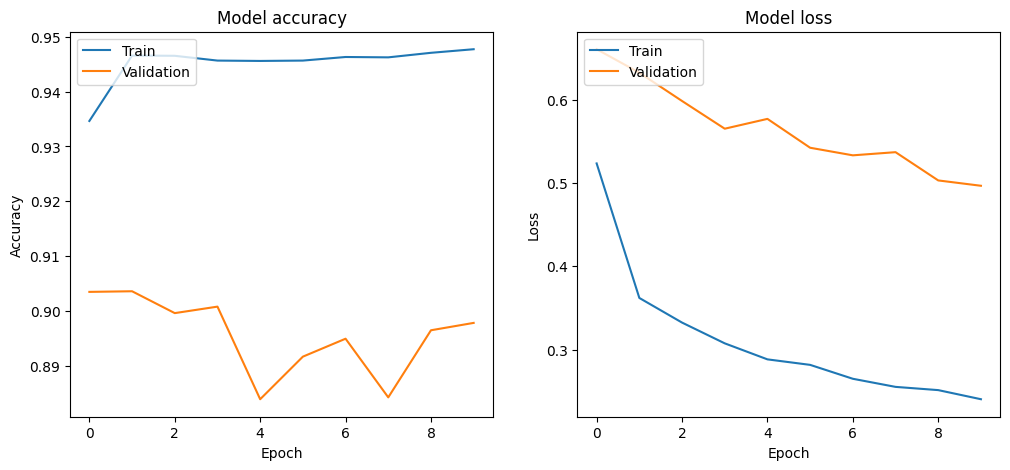

Training history visualization complete.


In [18]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

print("Training history visualization complete.")

### Step 7.3: Evaluate Model with Additional Metrics (Precision, Recall, F1-score)

In [19]:
from sklearn.metrics import classification_report
import numpy as np

# Make predictions on the test set
y_pred_one_hot = model.predict(X_test)

# Convert one-hot encoded predictions and true labels back to original tag indices
y_pred_indices = np.argmax(y_pred_one_hot, axis=-1)
y_true_indices = np.argmax(y_test_one_hot, axis=-1)

# Flatten the arrays to compute metrics across all tokens
# We need to filter out padding tokens (index 0 for '_' tag) from evaluation
# The actual tag mapping starts from 0 for '_' and 21 for 'O'
# We should exclude the padding tokens from the evaluation.

# Create masks to exclude padding tokens
# Assuming tag2idx['_'] is the padding tag index
padding_tag_idx = tag2idx['_']
mask = (y_true_indices != padding_tag_idx)

y_pred_flat = y_pred_indices[mask]
y_true_flat = y_true_indices[mask]

# Map indices back to original tag names for a more readable report
target_names = [idx2tag[i] for i in sorted(idx2tag.keys()) if i != padding_tag_idx]

# Generate a classification report
print("\nClassification Report (excluding padding tokens):\n")
print(classification_report(y_true_flat, y_pred_flat, target_names=target_names))

print("Model evaluation complete.")

121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step

Classification Report (excluding padding tokens):

               precision    recall  f1-score   support

    B-company       1.00      0.00      0.00       621
   B-facility       0.22      0.13      0.16       253
    B-geo-loc       0.45      0.12      0.19       881
      B-movie       0.00      0.00      0.00        33
B-musicartist       0.00      0.00      0.00       191
      B-other       0.08      0.00      0.01       584
     B-person       0.18      0.00      0.01       481
    B-product       0.00      0.00      0.00       246
 B-sportsteam       0.00      0.00      0.00       146
     B-tvshow       0.00      0.00      0.00        33
    I-company       0.00      0.00      0.00       265
   I-facility       0.14      0.08      0.10       366
    I-geo-loc       0.00      0.00      0.00       219
      I-movie       0.00      0.00      0.00        46
I-musicartist       0.00      0.00      0.00       140
      I-other       0.04 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 8. Prediction & Deployment
### Step 8.1: Prediction on Sample Sentences

### Step 8.1: SeqEval Entity Evaluation (Precision, Recall, F1 for Named Entities)

In [20]:
# !pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=968e2e0612414c7cd7a44cd2b7755100a2cdd2ea45fc8a1c0d2055155b81b91e
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [21]:
from seqeval.metrics import classification_report

# Convert indices back to original tag names for seqeval
# Filter out padding tokens and reconstruct the original sequences of tags

def get_original_tag_sequences(indexed_sequences, tag_mapping, padding_idx):
    original_sequences = []
    for seq_of_indices in indexed_sequences:
        # Filter out padding indices and map to actual tags
        original_sequence = [tag_mapping[idx] for idx in seq_of_indices if idx != padding_idx]
        original_sequences.append(original_sequence)
    return original_sequences

# Get true and predicted tag sequences, excluding padding
y_true_seq = get_original_tag_sequences(y_true_indices, idx2tag, padding_tag_idx)
y_pred_seq = get_original_tag_sequences(y_pred_indices, idx2tag, padding_tag_idx)

# Ensure the lengths match for evaluation
# In some cases, due to filtering, the lengths might not perfectly match if original sentences were truncated due to MAX_PAD_LEN.
# For proper seqeval, we should align them based on the actual (non-padded) lengths.
# We will use the lengths of the true sequences as the reference.

aligned_y_pred_seq = []
for i, true_seq in enumerate(y_true_seq):
    pred_seq_item = y_pred_seq[i]
    if len(pred_seq_item) > len(true_seq):
        aligned_y_pred_seq.append(pred_seq_item[:len(true_seq)])
    else:
        aligned_y_pred_seq.append(pred_seq_item)

# Generate seqeval classification report
print("\nSeqEval Classification Report:\n")
print(classification_report(y_true_seq, aligned_y_pred_seq))



SeqEval Classification Report:



/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

     company       1.00      0.00      0.00       621
    facility       0.07      0.06      0.06       253
     geo-loc       0.36      0.10      0.15       881
       movie       0.00      0.00      0.00        33
 musicartist       0.00      0.00      0.00       191
       other       0.00      0.00      0.00       584
      person       0.12      0.00      0.01       481
     product       0.00      0.00      0.00       246
  sportsteam       0.00      0.00      0.00       146
      tvshow       0.00      0.00      0.00        33

   micro avg       0.16      0.03      0.05      3469
   macro avg       0.15      0.02      0.02      3469
weighted avg       0.29      0.03      0.04      3469



### Step 8.3: Error Analysis (Confusion Matrix of tokens)

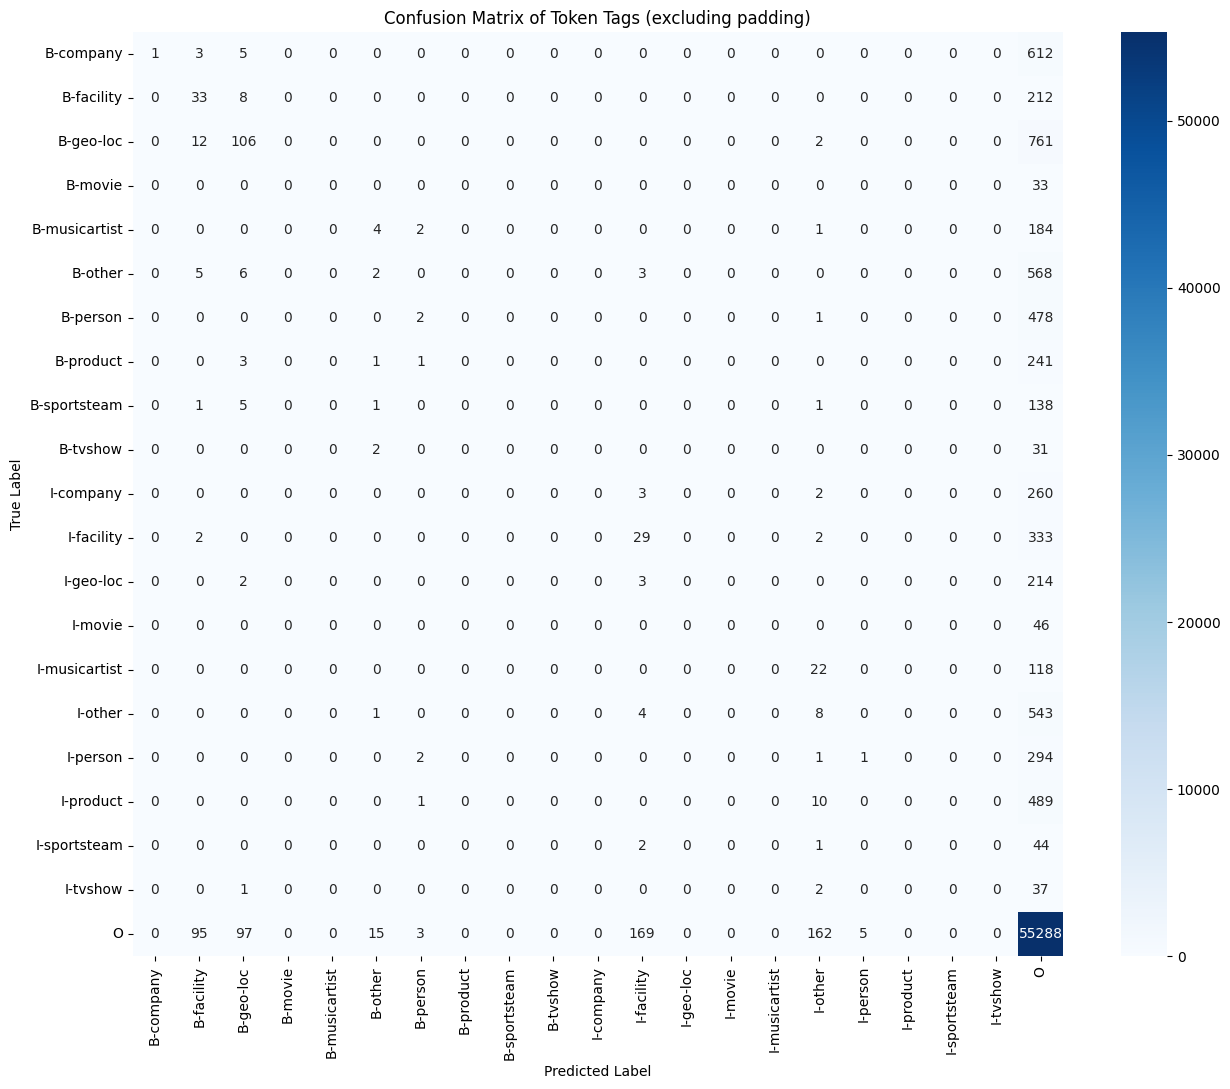

Confusion matrix visualization complete.

Examples of misclassified tokens:
True: B-other         Predicted: O
True: I-other         Predicted: O
True: I-other         Predicted: O
True: I-other         Predicted: O
True: I-other         Predicted: O
True: I-other         Predicted: O
True: O               Predicted: I-other
True: O               Predicted: I-other
True: B-movie         Predicted: O
True: B-person        Predicted: O


In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# We already have y_true_flat and y_pred_flat from the previous sklearn classification report cell
# These arrays contain the true and predicted tag indices for non-padding tokens.

# Generate the confusion matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)

# Create labels for the confusion matrix (excluding padding token '_')
# Ensure the order matches the `tag2idx` values for non-padding tags
# Fix: Iterate over sorted indices of idx2tag, not keys of tag2idx
cm_labels = [idx2tag[i] for i in sorted(idx2tag.keys()) if i != padding_tag_idx]

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Token Tags (excluding padding)')
plt.show()

print("Confusion matrix visualization complete.")

# Optionally, print some misclassified examples (words and their true/predicted tags)
print("\nExamples of misclassified tokens:")
misclassified_count = 0
max_examples_to_print = 10

for i in range(len(y_true_flat)):
    if y_true_flat[i] != y_pred_flat[i]:
        true_tag = idx2tag[y_true_flat[i]]
        pred_tag = idx2tag[y_pred_flat[i]]

        # Find the original word associated with this flat index.
        # This is more complex as y_true_flat and y_pred_flat are flattened and masked.
        # A simpler approach for examples might be to iterate through sentences and find errors.
        # For now, let's just print the tags.
        if misclassified_count < max_examples_to_print:
            print(f"True: {true_tag:<15} Predicted: {pred_tag}")
            misclassified_count += 1
        else:
            break

if misclassified_count == 0:
    print("No misclassified tokens found in the sampled output.")

## 5. Robust Handling of Data Imbalance [Advanced Enhancements]
### Step 5.1: Data Augmentation (Synonym swap, context masking)

In [23]:
# For data augmentation, we'll implement a simple synonym replacement strategy for words within named entities.
# This requires a synonym dictionary. For a more robust solution, a library like nlpaug or textattack could be used.

# NOTE: This is a basic example. In a real-world scenario, you would need a more sophisticated approach
# (e.g., using WordNet, pre-trained word embeddings for similarity, or more advanced NLP libraries).

from nltk.corpus import wordnet
import random

# Download wordnet if not already downloaded
import nltk
nltk.download('wordnet')

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace('_', ' ').lower()
            if synonym != word.lower(): # Exclude the original word itself
                synonyms.add(synonym)
    return list(synonyms)

def augment_sentence_synonym_replacement(sentence_tokens_tags, augmentation_ratio=0.1, synonym_threshold=1):
    augmented_sentences = []
    words_to_augment = []

    for word, tag in sentence_tokens_tags:
        # Only consider augmenting words that are part of an entity (not 'O' or '_')
        if tag != 'O' and tag != '_':
            words_to_augment.append((word, tag))

    if not words_to_augment: # No entities to augment in this sentence
        return [sentence_tokens_tags] # Return original sentence wrapped in a list

    num_augmentations = int(len(words_to_augment) * augmentation_ratio)
    if num_augmentations == 0 and len(words_to_augment) > 0: # Ensure at least one augmentation if entities exist
        num_augmentations = 1

    # Generate multiple augmented versions
    for _ in range(num_augmentations):
        new_sentence = list(sentence_tokens_tags) # Create a mutable copy
        # Randomly select an entity word to replace
        word_to_replace_idx = random.randrange(len(words_to_augment))
        original_word, original_tag = words_to_augment[word_to_replace_idx]

        synonyms = get_synonyms(original_word)
        if synonyms:
            # Find the position of the original word in the sentence
            # Note: This is simplified and assumes unique word instances. A better way would track original indices.
            for i, (w, t) in enumerate(new_sentence):
                if w == original_word and t == original_tag:
                    new_sentence[i] = (random.choice(synonyms), original_tag) # Replace with a random synonym
                    break
        augmented_sentences.append(new_sentence)

    return augmented_sentences

# Let's apply this to our training samples. This can be computationally intensive.
print("Applying data augmentation to training samples...")
augmented_train_samples = []
for sample in train_samples:
    augmented_train_samples.extend(augment_sentence_synonym_replacement(sample, augmentation_ratio=0.5))

# Combine original and augmented samples
print(f"Original training samples: {len(train_samples)}")
print(f"Augmented training samples generated: {len(augmented_train_samples) - len(train_samples)}")

# For simplicity, let's just add the augmented samples to the training data.
# In a more rigorous setup, you might balance classes more explicitly.
all_train_samples_augmented = train_samples + augmented_train_samples

print(f"Total training samples after augmentation: {len(all_train_samples_augmented)}")

# Re-run preprocessing steps (3.3 to 3.5) with the augmented data
print("Re-running preprocessing steps with augmented data...")

# 3.3 Convert Sentences to Indices
indexed_train_samples_aug = convert_to_indices(all_train_samples_augmented, word2idx, tag2idx)

# 3.4 Padding Sequences
X_train_aug, y_train_aug = pad_sequences(indexed_train_samples_aug, MAX_PAD_LEN, pad_word_idx, pad_tag_idx)

# 3.5 One-Hot Encoding
y_train_one_hot_aug = tf.keras.utils.to_categorical(y_train_aug, num_classes=num_tags)

print("Preprocessing with augmented data complete.")
print(f"Shape of X_train_aug: {X_train_aug.shape}")
print(f"Shape of y_train_one_hot_aug: {y_train_one_hot_aug.shape}")

# Now, we should retrain the model with this augmented data.

[nltk_data] Downloading package wordnet to /root/nltk_data...


Applying data augmentation to training samples...
Original training samples: 2394
Augmented training samples generated: 367
Total training samples after augmentation: 5155
Re-running preprocessing steps with augmented data...
Preprocessing with augmented data complete.
Shape of X_train_aug: (5155, 29)
Shape of y_train_one_hot_aug: (5155, 29, 22)


### Step 7.1 (Re-run): Train Model with Augmented Data & Validate Model (Save metric histories)

In [24]:
print("Starting model retraining with augmented data...")

# Retrain the model using the augmented data
# We'll use the same model instance, effectively continuing training or resetting if needed.
# For a clean retraining, you might want to re-initialize the model architecture before training.
# For simplicity, we'll continue training the existing model. If you want to train from scratch,
# re-run the model definition and compilation cells before this cell.

history_augmented = model.fit(
    X_train_aug, y_train_one_hot_aug,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS, # Use the same number of epochs for comparison
    validation_data=(X_test, y_test_one_hot),
    verbose=1
)

print("Model retraining with augmented data complete.")
print("New training history (history_augmented) saved.")

Starting model retraining with augmented data...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 54s 331ms/step - accuracy: 0.9317 - loss: 0.2873 - val_accuracy: 0.8903 - val_loss: 0.5034
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 46s 281ms/step - accuracy: 0.9349 - loss: 0.2621 - val_accuracy: 0.8811 - val_loss: 0.5219
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.9398 - loss: 0.2358 - val_accuracy: 0.8841 - val_loss: 0.5260
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 254ms/step - accuracy: 0.9445 - loss: 0.2097 - val_accuracy: 0.8952 - val_loss: 0.5007
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 254ms/step - accuracy: 0.9491 - loss: 0.1895 - val_accuracy: 0.8879 - val_loss: 0.5301
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.9547 - loss: 0.1664 - val_accuracy: 0.8839 - val_loss: 0.5322
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 241ms/step - accuracy: 0.9594 - loss: 0.1477 - val_accuracy: 0.8931 - val_loss: 0.5478
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━

### Step 7.3 (Re-run): Evaluate Model with Additional Metrics (Precision, Recall, F1-score) after Augmentation

In [25]:
from sklearn.metrics import classification_report
import numpy as np

# Make predictions on the test set using the retrained model
y_pred_one_hot_aug = model.predict(X_test)

# Convert one-hot encoded predictions and true labels back to original tag indices
y_pred_indices_aug = np.argmax(y_pred_one_hot_aug, axis=-1)
# y_true_indices remains the same as X_test, y_test_one_hot were not augmented

# Flatten the arrays to compute metrics across all tokens, excluding padding
mask = (y_true_indices != padding_tag_idx)

y_pred_flat_aug = y_pred_indices_aug[mask]
y_true_flat = y_true_indices[mask]

# Map indices back to original tag names for a more readable report
target_names = [idx2tag[i] for i in sorted(idx2tag.keys()) if i != padding_tag_idx]

# Generate a classification report
print("\nClassification Report (excluding padding tokens) after Augmentation:\n")
print(classification_report(y_true_flat, y_pred_flat_aug, target_names=target_names))

print("Model evaluation after augmentation complete.")

121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step

Classification Report (excluding padding tokens) after Augmentation:

               precision    recall  f1-score   support

    B-company       0.25      0.04      0.07       621
   B-facility       0.25      0.20      0.22       253
    B-geo-loc       0.48      0.23      0.31       881
      B-movie       0.00      0.00      0.00        33
B-musicartist       0.22      0.01      0.02       191
      B-other       0.11      0.11      0.11       584
     B-person       0.16      0.10      0.12       481
    B-product       0.07      0.01      0.01       246
 B-sportsteam       0.00      0.00      0.00       146
     B-tvshow       0.12      0.03      0.05        33
    I-company       0.26      0.02      0.04       265
   I-facility       0.25      0.18      0.21       366
    I-geo-loc       0.22      0.04      0.06       219
      I-movie       0.00      0.00      0.00        46
I-musicartist       0.07      0.01      0.02       140
      

### Step 8.1 (Re-run): SeqEval Entity Evaluation after Augmentation

In [26]:
from seqeval.metrics import classification_report as seqeval_report

# Get true and predicted tag sequences, excluding padding
# y_true_seq remains the same
y_pred_seq_aug = get_original_tag_sequences(y_pred_indices_aug, idx2tag, padding_tag_idx)

# Ensure the lengths match for evaluation
aligned_y_pred_seq_aug = []
for i, true_seq in enumerate(y_true_seq):
    pred_seq_item = y_pred_seq_aug[i]
    if len(pred_seq_item) > len(true_seq):
        aligned_y_pred_seq_aug.append(pred_seq_item[:len(true_seq)])
    else:
        aligned_y_pred_seq_aug.append(pred_seq_item)

# Generate seqeval classification report
print("\nSeqEval Classification Report after Augmentation:\n")
print(seqeval_report(y_true_seq, aligned_y_pred_seq_aug))

print("SeqEval evaluation after augmentation complete.")


SeqEval Classification Report after Augmentation:

              precision    recall  f1-score   support

     company       0.25      0.05      0.08       621
    facility       0.11      0.11      0.11       253
     geo-loc       0.37      0.19      0.25       881
       movie       0.00      0.00      0.00        33
 musicartist       0.04      0.01      0.01       191
       other       0.04      0.07      0.05       584
      person       0.10      0.09      0.10       481
     product       0.02      0.00      0.01       246
  sportsteam       0.00      0.00      0.00       146
      tvshow       0.07      0.03      0.04        33

   micro avg       0.13      0.09      0.11      3469
   macro avg       0.10      0.05      0.06      3469
weighted avg       0.17      0.09      0.11      3469

SeqEval evaluation after augmentation complete.


### Step 5.2: Class Weight Training Configuration

In [27]:
from collections import Counter

print("Calculating class weights...")

# Flatten the y_train_aug array, excluding padding tags
# y_train_aug is (num_samples, MAX_PAD_LEN)
flat_y_train_tags = y_train_aug[y_train_aug != tag2idx['_']].numpy().flatten()

# Count occurrences of each tag
tag_counts = Counter(flat_y_train_tags)

# Calculate total number of non-padding tags
total_non_padding_tags = sum(tag_counts.values())

# Calculate class weights based on inverse frequency
# Higher weight for less frequent classes
class_weights = {}
for tag_idx in range(num_tags): # Iterate through all possible tag indices
    count = tag_counts.get(tag_idx, 0)
    if count > 0:
        # Inverse frequency weighting: total_samples / (num_classes * count)
        # Or simply total_non_padding_tags / count for relative inverse frequency
        class_weights[tag_idx] = total_non_padding_tags / (num_tags * count)
    else:
        # Assign a very high weight or a placeholder for unseen tags if necessary
        # For now, let's assign a reasonable weight (e.g., average of others) or 0
        # Assigning 0 might cause issues if a tag has no representation in training data,
        # but it might also be desired if we don't want to optimize for it.
        # Let's set it to 1.0 (neutral) or average if it's truly absent in training labels.
        class_weights[tag_idx] = 1.0 # Neutral weight for tags not present in flat_y_train_tags

# Ensure class_weights are ordered by index
ordered_class_weights = {i: class_weights.get(i, 1.0) for i in sorted(class_weights.keys())}

print("Class weights calculated:")
for idx, weight in ordered_class_weights.items():
    print(f"  Tag: {idx2tag[idx]:<15} (idx: {idx:<2}) Weight: {weight:.4f}")

# Prepare class_weights for Keras fit method (must be a dictionary mapping class indices to weights)
# Keras expects class indices as integers, not one-hot encoded vectors.
# The `to_categorical` function expects integer labels for classification_report
# so this mapping should be directly usable.

print("Class weight configuration complete.")

Calculating class weights...
Class weights calculated:
  Tag: _               (idx: 0 ) Weight: 1.0000
  Tag: B-company       (idx: 1 ) Weight: 11.2354
  Tag: B-facility      (idx: 2 ) Weight: 15.4773
  Tag: B-geo-loc       (idx: 3 ) Weight: 6.2419
  Tag: B-movie         (idx: 4 ) Weight: 44.1778
  Tag: B-musicartist   (idx: 5 ) Weight: 26.0018
  Tag: B-other         (idx: 6 ) Weight: 6.6331
  Tag: B-person        (idx: 7 ) Weight: 3.8660
  Tag: B-product       (idx: 8 ) Weight: 16.2511
  Tag: B-sportsteam    (idx: 9 ) Weight: 35.2738
  Tag: B-tvshow        (idx: 10) Weight: 56.8790
  Tag: I-company       (idx: 11) Weight: 41.7460
  Tag: I-facility      (idx: 12) Weight: 14.2197
  Tag: I-geo-loc       (idx: 13) Weight: 29.3569
  Tag: I-movie         (idx: 14) Weight: 31.8204
  Tag: I-musicartist   (idx: 15) Weight: 19.6983
  Tag: I-other         (idx: 16) Weight: 3.8432
  Tag: I-person        (idx: 17) Weight: 6.8221
  Tag: I-product       (idx: 18) Weight: 14.0442
  Tag: I-sportsteam 

### Step 7.1 (Re-run): Train Model with Augmented Data and Class Weights

### Step 5.3: Advanced Loss Engineering (Introduce Focal Loss)

In [28]:
import tensorflow as tf
import tensorflow.keras.backend as K

def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        # y_true is integer-encoded: (batch_size, sequence_length)
        # y_pred is softmax probabilities: (batch_size, sequence_length, num_tags)

        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

        batch_size = tf.shape(y_true)[0]
        sequence_length = tf.shape(y_true)[1]
        num_tags = tf.shape(y_pred)[-1]

        # Flatten y_true and y_pred for per-element processing
        # y_true_flat: (batch_size * sequence_length,)
        # y_pred_flat: (batch_size * sequence_length, num_tags)
        y_true_flat = tf.reshape(tf.cast(y_true, dtype=tf.int32), [-1])
        y_pred_flat = tf.reshape(y_pred, [-1, num_tags])

        # Convert y_true_flat to one-hot encoding: (B*S, N)
        y_true_one_hot = tf.one_hot(y_true_flat, depth=num_tags)

        # Calculate cross-entropy: (B*S, N)
        cross_entropy = -K.log(y_pred_flat)

        # Calculate pt (probability of true class): (B*S,)
        pt = tf.reduce_sum(y_true_one_hot * y_pred_flat, axis=-1)
        pt = K.clip(pt, epsilon, 1. - epsilon)

        # Calculate alpha_t: (B*S, N)
        alpha_t = y_true_one_hot * alpha + (1 - y_true_one_hot) * (1 - alpha)

        # Calculate focal term (1 - pt)^gamma: (B*S, 1)
        focal_term = K.pow(1. - K.expand_dims(pt, axis=-1), gamma)

        # Combine terms element-wise: (B*S, N)
        focal_loss_value_flat = alpha_t * focal_term * cross_entropy

        # Sum over classes to get the actual focal loss for the true class per element: (B*S,)
        loss_per_element = K.sum(focal_loss_value_flat * y_true_one_hot, axis=-1)

        # --- IMPORTANT: Apply masking to ignore padding tokens ---
        # Assuming padding_tag_idx is 0 (for '_') as defined in tag2idx['_']
        padding_tag_idx = tf.constant(0, dtype=tf.int32)
        mask_flat = tf.cast(tf.not_equal(y_true_flat, padding_tag_idx), dtype=tf.float32)

        # Apply mask to loss_per_element
        masked_loss = loss_per_element * mask_flat

        # Calculate the sum of the non-padded losses
        sum_loss = tf.reduce_sum(masked_loss)
        # Calculate the number of non-padded elements
        num_non_padded_elements = tf.reduce_sum(mask_flat)

        # Return the mean loss over non-padded elements. Add epsilon to avoid division by zero.
        return sum_loss / (num_non_padded_elements + epsilon)

    return focal_loss_fixed

print("Focal Loss function defined (explicitly flattened, reshaped, masked, and scalar output).")

Focal Loss function defined (explicitly flattened, reshaped, masked, and scalar output).


### Step 7.1 (Re-run): Train Model with Augmented Data and Focal Loss

In [29]:
print("Starting model retraining with augmented data and Focal Loss...")

# Re-initialize the model architecture
# This ensures we start training from a fresh set of weights.

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, TimeDistributed
from tensorflow.keras.optimizers import Adam

# Define the input layer for word indices
word_input = Input(shape=(MAX_PAD_LEN,), dtype='int32', name='word_input')

# Create an embedding layer using the pre-trained GloVe embedding matrix
embedding_layer = Embedding(
    input_dim=vocabulary_size,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=False,
    mask_zero=False # Set to False to let the custom loss handle masking explicitly
)(word_input)

# Add a Bidirectional LSTM layer
bi_lstm = Bidirectional(LSTM(units=128, return_sequences=True, recurrent_dropout=0.1))(
    embedding_layer
)

# Add a TimeDistributed Dense layer for outputting a tag for each word in the sequence
output_layer = TimeDistributed(Dense(num_tags, activation='softmax'))(bi_lstm)

# Create the new model instance
model_focal_loss = Model(inputs=word_input, outputs=output_layer)

# Compile the new model with Focal Loss
model_focal_loss.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=['accuracy']
)

# Train the model with Focal Loss
history_focal_loss = model_focal_loss.fit(
    X_train_aug,
    y_train_aug, # Use integer-encoded labels
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test), # Use integer-encoded labels for validation
    verbose=1
)

print("Model retraining with augmented data and Focal Loss complete.")
print("New training history (history_focal_loss) saved.")

Starting model retraining with augmented data and Focal Loss...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 43s 230ms/step - accuracy: 0.6150 - loss: 0.0928 - val_accuracy: 0.4999 - val_loss: 0.0953
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 31s 191ms/step - accuracy: 0.6205 - loss: 0.0625 - val_accuracy: 0.4989 - val_loss: 0.0872
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 191ms/step - accuracy: 0.6219 - loss: 0.0528 - val_accuracy: 0.4983 - val_loss: 0.0817
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 31s 193ms/step - accuracy: 0.6238 - loss: 0.0468 - val_accuracy: 0.4983 - val_loss: 0.0848
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 33s 202ms/step - accuracy: 0.6263 - loss: 0.0420 - val_accuracy: 0.4920 - val_loss: 0.0849
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 31s 191ms/step - accuracy: 0.6287 - loss: 0.0376 - val_accuracy: 0.4941 - val_loss: 0.0817
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 31s 193ms/step - accuracy: 0.6309 - loss: 0.0331 - val_accuracy: 0.4985 - val_loss: 0.0827
Epoch 8/10
162/162 

### Step 7.3 (Re-run): Evaluate Model with Additional Metrics (Precision, Recall, F1-score) after Focal Loss

In [30]:
from sklearn.metrics import classification_report
import numpy as np

# Make predictions on the test set using the model trained with Focal Loss
y_pred_one_hot_focal_loss = model_focal_loss.predict(X_test)

# Convert one-hot encoded predictions and true labels back to original tag indices
y_pred_indices_focal_loss = np.argmax(y_pred_one_hot_focal_loss, axis=-1)
# y_true_indices remains the same as X_test, y_test were not augmented

# Flatten the arrays to compute metrics across all tokens, excluding padding
mask = (y_true_indices != padding_tag_idx)

y_pred_flat_focal_loss = y_pred_indices_focal_loss[mask]
y_true_flat = y_true_indices[mask]

# Define labels and target names explicitly to avoid mismatch errors
# Exclude the padding_tag_idx (0) from both labels and target_names
labels_for_report = [i for i in sorted(idx2tag.keys()) if i != padding_tag_idx]
target_names_for_report = [idx2tag[label] for label in labels_for_report]

# Generate a classification report
print("\nClassification Report (excluding padding tokens) after Focal Loss:\n")
print(classification_report(y_true_flat, y_pred_flat_focal_loss, labels=labels_for_report, target_names=target_names_for_report))

print("Model evaluation after Focal Loss complete.")

121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step

Classification Report (excluding padding tokens) after Focal Loss:

               precision    recall  f1-score   support

    B-company       0.16      0.04      0.06       621
   B-facility       0.32      0.23      0.27       253
    B-geo-loc       0.50      0.31      0.39       881
      B-movie       0.00      0.00      0.00        33
B-musicartist       0.12      0.02      0.03       191
      B-other       0.12      0.10      0.11       584
     B-person       0.19      0.12      0.15       481
    B-product       0.07      0.04      0.05       246
 B-sportsteam       0.33      0.01      0.03       146
     B-tvshow       0.25      0.03      0.05        33
    I-company       0.08      0.00      0.01       265
   I-facility       0.27      0.22      0.24       366
    I-geo-loc       0.30      0.10      0.15       219
      I-movie       0.00      0.00      0.00        46
I-musicartist       0.04      0.01      0.02       140
      I-

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Step 8.1 (Re-run): SeqEval Entity Evaluation after Focal Loss

In [31]:
from seqeval.metrics import classification_report as seqeval_report

# y_true_seq is already generated from y_true_indices by filtering padding,
# so it represents the true, non-padded sequences.

# We need to prepare y_pred_seq_focal_loss such that its inner lists have the same length as y_true_seq
y_pred_seq_focal_loss_aligned = []
for i, true_seq in enumerate(y_true_seq):
    # Get the predicted tag indices for the current sentence, up to its true length
    # We don't filter out padding_tag_idx here, as seqeval expects 'O' (mapped from '_')
    # to be a valid tag within the sentence boundaries.
    pred_indices_for_sentence = y_pred_indices_focal_loss[i][:len(true_seq)]

    # Convert these indices to tags directly
    predicted_tags = [idx2tag[idx] for idx in pred_indices_for_sentence]
    y_pred_seq_focal_loss_aligned.append(predicted_tags)

# Generate seqeval classification report
print("\nSeqEval Classification Report after Focal Loss:\n")
print(seqeval_report(y_true_seq, y_pred_seq_focal_loss_aligned))

print("SeqEval evaluation after Focal Loss complete.")


SeqEval Classification Report after Focal Loss:



/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

     company       0.14      0.04      0.06       621
    facility       0.15      0.15      0.15       253
     geo-loc       0.40      0.26      0.31       881
       movie       0.00      0.00      0.00        33
 musicartist       0.02      0.01      0.01       191
       other       0.03      0.04      0.03       584
      person       0.11      0.09      0.10       481
     product       0.02      0.02      0.02       246
  sportsteam       0.29      0.01      0.03       146
      tvshow       0.11      0.03      0.05        33

   micro avg       0.15      0.10      0.12      3469
   macro avg       0.13      0.06      0.08      3469
weighted avg       0.17      0.10      0.12      3469

SeqEval evaluation after Focal Loss complete.


### Step 8.1 (Re-run): Prediction on Sample Sentences (with Focal Loss)

In [33]:
import numpy as np

def predict_entities(sentence, model, word2idx, idx2tag, max_pad_len, unk_token='<UNK>', pad_token='<PAD>'):
    # 1. Tokenize the input sentence
    words = sentence.split()

    # 2. Convert words to indices, handling unknown words
    indexed_words = [word2idx.get(word, word2idx[unk_token]) for word in words]

    # 3. Pad/truncate the sequence to MAX_PAD_LEN
    if len(indexed_words) > max_pad_len:
        padded_indexed_words = indexed_words[:max_pad_len]
    else:
        # Use the index for the PAD_TOKEN for padding
        padded_indexed_words = indexed_words + [word2idx[pad_token]] * (max_pad_len - len(indexed_words))

    # 4. Reshape for model input (batch_size, sequence_length)
    model_input = np.array([padded_indexed_words])

    # 5. Make prediction
    predictions = model.predict(model_input)

    # 6. Get the tag with the highest probability for each word
    predicted_tag_indices = np.argmax(predictions, axis=-1)[0]

    # 7. Convert predicted tag indices back to tag names
    # Only consider predictions for original words (before padding)
    original_length = len(words)
    predicted_tags = [idx2tag[idx] for idx in predicted_tag_indices[:original_length]]

    # 8. Combine words with their predicted tags
    entities = []
    for word, tag in zip(words, predicted_tags):
        if tag != 'O' and tag != '_': # Exclude 'O' (outside) and '_' (padding) tags
            entities.append((word, tag))

    return entities

# Example sentences for prediction
sample_sentences = [
    "Google's CEO Sundar Pichai visited the White House today.",
    "I watched 'The Matrix' last night, it was amazing.",
    "Apple released a new iPhone model in California.",
    "The game between Fnatic and G2 Esports will be in Berlin."
]

print("Helper function 'predict_entities' and 'sample_sentences' defined.")

Helper function 'predict_entities' and 'sample_sentences' defined.


In [34]:
print("Making predictions on sample sentences using model with Focal Loss:")
for i, sentence in enumerate(sample_sentences):
    print(f"\nSentence {i+1}: {sentence}")
    predicted_entities_focal_loss = predict_entities(sentence, model_focal_loss, word2idx, idx2tag, MAX_PAD_LEN, UNK_TOKEN, PAD_TOKEN)
    if predicted_entities_focal_loss:
        print("Predicted Entities (with Focal Loss):")
        for entity in predicted_entities_focal_loss:
            print(f"  - {entity[0]} ({entity[1]}) ")
    else:
        print("No named entities predicted (with Focal Loss).")

print("Sample sentence prediction with Focal Loss complete.")

Making predictions on sample sentences using model with Focal Loss:

Sentence 1: Google's CEO Sundar Pichai visited the White House today.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
Predicted Entities (with Focal Loss):
  - House (I-other) 
  - today. (I-other) 

Sentence 2: I watched 'The Matrix' last night, it was amazing.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Entities (with Focal Loss):
  - 'The (B-person) 

Sentence 3: Apple released a new iPhone model in California.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
No named entities predicted (with Focal Loss).

Sentence 4: The game between Fnatic and G2 Esports will be in Berlin.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Predicted Entities (with Focal Loss):
  - Fnatic (B-person) 
  - G2 (B-person) 
  - Esports (I-person) 
  - Berlin. (B-geo-loc) 
Sample sentence prediction with Focal Loss complete.


In [35]:
print("Starting model retraining with augmented data and class weights...")

# Retrain the model using the augmented data and class weights
# IMPORTANT: We need to re-initialize the model to train from scratch with new weights.
# Otherwise, it would continue training from the previous state, which isn't ideal for evaluating new strategies.

# Re-initialize the model architecture
# This assumes the model definition (Step 6.1) and compilation (Step 6.2) cells have been run, or their logic is repeated here.
# For simplicity, we will re-define and re-compile the model here.

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, TimeDistributed
from tensorflow.keras.optimizers import Adam
import numpy as np # Import numpy for sample_weights_for_fit

# Define the input layer for word indices
word_input = Input(shape=(MAX_PAD_LEN,), dtype='int32', name='word_input')

# Create an embedding layer using the pre-trained GloVe embedding matrix
embedding_layer = Embedding(
    input_dim=vocabulary_size,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=False, # Set to True if you want to fine-tune the embeddings
    mask_zero=True # Masking layer to ignore padding (0s) in sequences
)(word_input)

# Add a Bidirectional LSTM layer
bi_lstm = Bidirectional(LSTM(units=128, return_sequences=True, recurrent_dropout=0.1))(
    embedding_layer
)

# Add a TimeDistributed Dense layer for outputting a tag for each word in the sequence
output_layer = TimeDistributed(Dense(num_tags, activation='softmax'))(bi_lstm)

# Create the new model instance
model_with_weights = Model(inputs=word_input, outputs=output_layer)

# Compile the new model with the same optimizer and loss function
# Change loss to 'sparse_categorical_crossentropy' to work with integer labels (y_train_aug)
model_with_weights.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Manually create sample_weights for the fit method
sample_weights_for_fit = np.zeros_like(y_train_aug, dtype=float)
for i in range(y_train_aug.shape[0]):
    for j in range(y_train_aug.shape[1]):
        # Ensure tag_idx_at_timestep is an integer for dictionary lookup
        tag_idx_at_timestep = int(y_train_aug[i, j].numpy())
        sample_weights_for_fit[i, j] = ordered_class_weights.get(tag_idx_at_timestep, 1.0)

# Train the model with sample weights
history_class_weights = model_with_weights.fit(
    X_train_aug,
    y_train_aug, # Use integer-encoded labels when providing sample_weight
    sample_weight=sample_weights_for_fit, # Apply the calculated sample weights
    batch_size=BATCH_SIZE,
    epochs=EPOCHS, # Use the same number of epochs for comparison
    validation_data=(X_test, y_test), # Use integer-encoded labels for validation data as well
    verbose=1
)

print("Model retraining with augmented data and class weights complete.")
print("New training history (history_class_weights) saved.")

Starting model retraining with augmented data and class weights...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 48s 256ms/step - accuracy: 0.4201 - loss: 2.6729 - val_accuracy: 0.4035 - val_loss: 2.4065
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 40s 247ms/step - accuracy: 0.5504 - loss: 2.0197 - val_accuracy: 0.3906 - val_loss: 2.3995
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 40s 242ms/step - accuracy: 0.5747 - loss: 1.4922 - val_accuracy: 0.3981 - val_loss: 2.2835
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 42s 246ms/step - accuracy: 0.6019 - loss: 1.1288 - val_accuracy: 0.4236 - val_loss: 2.1836
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 44s 271ms/step - accuracy: 0.6130 - loss: 0.9294 - val_accuracy: 0.4364 - val_loss: 2.0881
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 45s 279ms/step - accuracy: 0.6323 - loss: 0.7485 - val_accuracy: 0.4629 - val_loss: 1.9257
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 40s 244ms/step - accuracy: 0.6512 - loss: 0.6081 - val_accuracy: 0.4675 - val_loss: 1.9327
Epoch 8/10
162/1

### Step 8.1 (Re-run): Prediction on Sample Sentences (with class weights)

In [36]:
print("Making predictions on sample sentences using model with class weights:")
for i, sentence in enumerate(sample_sentences):
    print(f"\nSentence {i+1}: {sentence}")
    predicted_entities_weighted = predict_entities(sentence, model_with_weights, word2idx, idx2tag, MAX_PAD_LEN, UNK_TOKEN, PAD_TOKEN)
    if predicted_entities_weighted:
        print("Predicted Entities (with class weights):")
        for entity in predicted_entities_weighted:
            print(f"  - {entity[0]} ({entity[1]}) ")
    else:
        print("No named entities predicted (with class weights).")

print("Sample sentence prediction with class weights complete.")

Making predictions on sample sentences using model with class weights:

Sentence 1: Google's CEO Sundar Pichai visited the White House today.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step
Predicted Entities (with class weights):
  - Google's (B-person) 
  - CEO (B-person) 
  - Sundar (B-person) 
  - Pichai (I-person) 
  - visited (I-other) 
  - White (B-other) 
  - House (I-geo-loc) 
  - today. (I-other) 

Sentence 2: I watched 'The Matrix' last night, it was amazing.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted Entities (with class weights):
  - I (B-other) 
  - watched (B-person) 
  - 'The (B-person) 
  - Matrix' (B-person) 
  - night, (B-person) 
  - amazing. (B-geo-loc) 

Sentence 3: Apple released a new iPhone model in California.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted Entities (with class weights):
  - Apple (I-person) 
  - iPhone (B-musicartist) 
  - model (I-musicartist) 
  - in (I-other) 
  - California. (B-geo-loc) 

Sentence 4: The game between Fnatic and G2 Esports wil

In [37]:
import numpy as np

def predict_entities(sentence, model, word2idx, idx2tag, max_pad_len, unk_token='<UNK>', pad_token='<PAD>'):
    # 1. Tokenize the input sentence
    words = sentence.split()

    # 2. Convert words to indices, handling unknown words
    indexed_words = [word2idx.get(word, word2idx[unk_token]) for word in words]

    # 3. Pad/truncate the sequence to MAX_PAD_LEN
    if len(indexed_words) > max_pad_len:
        padded_indexed_words = indexed_words[:max_pad_len]
    else:
        # Use the index for the PAD_TOKEN for padding
        padded_indexed_words = indexed_words + [word2idx[pad_token]] * (max_pad_len - len(indexed_words))

    # 4. Reshape for model input (batch_size, sequence_length)
    model_input = np.array([padded_indexed_words])

    # 5. Make prediction
    predictions = model.predict(model_input)

    # 6. Get the tag with the highest probability for each word
    predicted_tag_indices = np.argmax(predictions, axis=-1)[0]

    # 7. Convert predicted tag indices back to tag names
    # Only consider predictions for original words (before padding)
    original_length = len(words)
    predicted_tags = [idx2tag[idx] for idx in predicted_tag_indices[:original_length]]

    # 8. Combine words with their predicted tags
    entities = []
    for word, tag in zip(words, predicted_tags):
        if tag != 'O' and tag != '_': # Exclude 'O' (outside) and '_' (padding) tags
            entities.append((word, tag))

    return entities

# Example sentences for prediction
sample_sentences = [
    "Google's CEO Sundar Pichai visited the White House today.",
    "I watched 'The Matrix' last night, it was amazing.",
    "Apple released a new iPhone model in California.",
    "The game between Fnatic and G2 Esports will be in Berlin."
]

print("Making predictions on sample sentences:")
for i, sentence in enumerate(sample_sentences):
    print(f"\nSentence {i+1}: {sentence}")
    predicted_entities = predict_entities(sentence, model, word2idx, idx2tag, MAX_PAD_LEN, UNK_TOKEN, PAD_TOKEN)
    if predicted_entities:
        print("Predicted Entities:")
        for entity in predicted_entities:
            print(f"  - {entity[0]} ({entity[1]}) ")
    else:
        print("No named entities predicted.")

print("Sample sentence prediction complete.")

Making predictions on sample sentences:

Sentence 1: Google's CEO Sundar Pichai visited the White House today.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 861ms/step
Predicted Entities:
  - House (I-other) 
  - today. (I-other) 

Sentence 2: I watched 'The Matrix' last night, it was amazing.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
No named entities predicted.

Sentence 3: Apple released a new iPhone model in California.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
No named entities predicted.

Sentence 4: The game between Fnatic and G2 Esports will be in Berlin.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted Entities:
  - Fnatic (B-person) 
  - G2 (B-person) 
  - Esports (I-person) 
  - Berlin. (B-geo-loc) 
Sample sentence prediction complete.


### Step 8.2: Save/Export Model

In [38]:
# Define a filename for the model
model_filename = 'bilstm_ner_model.keras'

# Save the entire model to a .keras zip archive
model.save(model_filename)

print(f"Model saved successfully to {model_filename}")

# To load the model later:
# from tensorflow.keras.models import load_model
# loaded_model = load_model(model_filename)


Model saved successfully to bilstm_ner_model.keras


<Axes: xlabel='keys'>

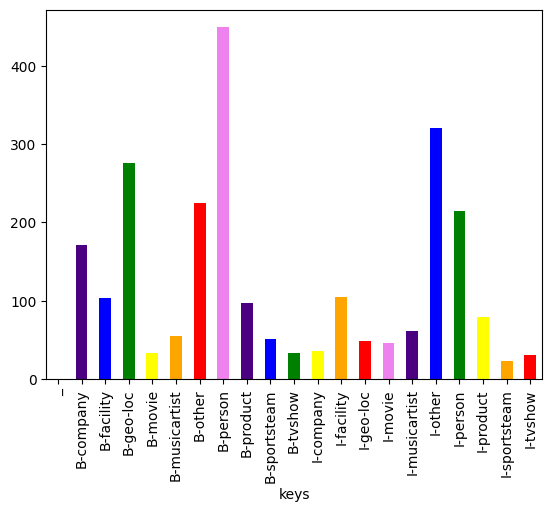

In [39]:
counts.pop('O')
counts_df = pd.DataFrame({'keys': list(counts.keys()), 'values': list(counts.values())})
counts_df.plot.bar(x='keys', y='values', legend=False, color=colors)

In [40]:
display(train_samples[:5])

[[('@SammieLynnsMom', 'O'),
  ('@tg10781', 'O'),
  ('they', 'O'),
  ('will', 'O'),
  ('be', 'O'),
  ('all', 'O'),
  ('done', 'O'),
  ('by', 'O'),
  ('Sunday', 'O'),
  ('trust', 'O'),
  ('me', 'O'),
  ('*wink*', 'O')],
 [('Made', 'O'),
  ('it', 'O'),
  ('back', 'O'),
  ('home', 'O'),
  ('to', 'O'),
  ('GA', 'B-geo-loc'),
  ('.', 'O'),
  ('It', 'O'),
  ('sucks', 'O'),
  ('not', 'O'),
  ('to', 'O'),
  ('be', 'O'),
  ('at', 'O'),
  ('Disney', 'B-facility'),
  ('world', 'I-facility'),
  (',', 'O'),
  ('but', 'O'),
  ('its', 'O'),
  ('good', 'O'),
  ('to', 'O'),
  ('be', 'O'),
  ('home', 'O'),
  ('.', 'O'),
  ('Time', 'O'),
  ('to', 'O'),
  ('start', 'O'),
  ('planning', 'O'),
  ('the', 'O'),
  ('next', 'O'),
  ('Disney', 'B-facility'),
  ('World', 'I-facility'),
  ('trip', 'O'),
  ('.', 'O')],
 [("'", 'O'),
  ('Breaking', 'B-movie'),
  ('Dawn', 'I-movie'),
  ("'", 'O'),
  ('Returns', 'O'),
  ('to', 'O'),
  ('Vancouver', 'B-geo-loc'),
  ('on', 'O'),
  ('January', 'O'),
  ('11th', 'O'),
  ('h

## 9. BERT/DistilBERT Model for NER

### Step 9.1: Install Hugging Face Transformers Library

First, we need to install the `transformers` library, which provides access to pre-trained BERT models and tokenizers.

In [41]:
!pip install transformers datasets seqeval

### Step 9.2: Load Pre-trained DistilBERT Tokenizer and Model

We will use `DistilBERT` for its efficiency. We'll load its tokenizer and a model with a token classification head suitable for NER.

In [70]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch

# Choose a pre-trained model checkpoint
model_checkpoint = "distilbert-base-uncased"

# Load the tokenizer
bert_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Prepare label mappings for the model
# idx2tag and tag2idx are already defined from previous steps

# Load the model with a token classification head
# num_labels should be the total number of unique tags in your schema
bert_model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(tag2idx),
    id2label=idx2tag, # Correctly pass the integer-to-string mapping
    label2id=tag2idx, # Correctly pass the string-to-integer mapping
)

print(f"DistilBERT Tokenizer and Model loaded from: {model_checkpoint}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Tokenizer and Model loaded from: distilbert-base-uncased


### Step 9.3: Preprocess Data for DistilBERT

BERT models require specific input formats, including token IDs, attention masks. We also need to align our NER tags with the BERT subword tokenization.

In [71]:
def tokenize_and_align_labels(samples, tokenizer, tag_to_idx, max_len=MAX_PAD_LEN):
    tokenized_inputs = {'input_ids': [], 'attention_mask': [], 'labels': []}

    for sentence_tokens_tags in samples:
        words = [word for word, _ in sentence_tokens_tags]
        tags = [tag for _, tag in sentence_tokens_tags]

        # Tokenize the words in the sentence
        # We use is_split_into_words=True because we have a list of words
        tokens = tokenizer(words, is_split_into_words=True, truncation=True, padding='max_length', max_length=max_len)

        word_ids = tokens.word_ids(batch_index=0)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # Special tokens (like [CLS], [SEP]) get a None word_idx.
            # We assign them a special label ID (-100) to be ignored by the loss function.
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                # Only label the first token of a given word.
                # Assign the tag of the original word.
                label_ids.append(tag_to_idx[tags[word_idx]])
            else:
                # For subword tokens subsequent to the first one, assign -100 to ignore them from loss calculation.
                label_ids.append(-100)
            previous_word_idx = word_idx

        tokenized_inputs['input_ids'].append(tokens['input_ids'][0])
        tokenized_inputs['attention_mask'].append(tokens['attention_mask'][0])
        tokenized_inputs['labels'].append(label_ids)

    return tokenized_inputs

# Tokenize and align labels for training and testing data
bert_train_data = tokenize_and_align_labels(train_samples, bert_tokenizer, tag2idx, MAX_PAD_LEN)
bert_test_data = tokenize_and_align_labels(test_samples, bert_tokenizer, tag2idx, MAX_PAD_LEN)

print("BERT-compatible data preprocessing complete.")
print(f"First 5 tokenized train labels: {bert_train_data['labels'][:5]}")

BERT-compatible data preprocessing complete.
First 5 tokenized train labels: [[-100, 21, -100, -100, -100, -100, -100, 21, -100, -100, -100, -100, -100, -100, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, -100, -100, -100, -100, -100], [-100, 21, 21, 21, 21, 21, 3, 21, 21, 21, 21, 21, 21, 21, 2, 12, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, -100], [-100, 21, 4, 14, 21, 21, 21, 3, 21, 21, 21, 21, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100], [-100, 21, -100, -100, -100, -100, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, -100, -100, -100, -100, 21, 21, -100], [-100, 21, -100, -100, -100, 21, 21, 21, 21, 21, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]]


### Step 9.4: Create PyTorch Datasets

We'll create custom PyTorch `Dataset` objects to prepare our data for the Hugging Face `Trainer`.

In [72]:
from torch.utils.data import Dataset


class NERDataset(Dataset):
    def __init__(self, encoded_data):
        self.input_ids = encoded_data["input_ids"]
        self.attention_mask = encoded_data["attention_mask"]
        self.labels = encoded_data["labels"]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = NERDataset(bert_train_data)
test_dataset = NERDataset(bert_test_data)

print("PyTorch datasets created successfully.")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

PyTorch datasets created successfully.
Train dataset size: 2394
Test dataset size: 3850


### Step 9.5: Define `compute_metrics` function

We need a function to compute evaluation metrics (precision, recall, F1-score) using `seqeval` for token classification.

In [73]:
import numpy as np
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [idx2tag[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [idx2tag[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }

### Step 9.6: Configure and Train the DistilBERT Model

Now, we'll use the Hugging Face `Trainer` API to fine-tune our DistilBERT model. This involves setting `TrainingArguments` and initializing the `Trainer`.

In [74]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./distilbert_ner_outputs",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_dir="./logs_distilbert",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    run_name="distilbert_ner_run"
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Starting DistilBERT model training...")
trainer.train()
print("DistilBERT model training complete.")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting DistilBERT model training...


RuntimeError: The size of tensor a (16) must match the size of tensor b (512) at non-singleton dimension 1

## 10. BERT-base Model for NER (Re-implementation)

### Step 10.1: Load Pre-trained BERT Tokenizer and Preprocess Data

We will use `bert-base-uncased` for the model. This involves loading its tokenizer and defining a function to preprocess our data into a format suitable for BERT models, including subword tokenization and label alignment.

In [77]:
from transformers import AutoTokenizer

# Initialize a tokenizer for bert-base-uncased
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_and_align_labels(sentence_tokens, tags, tag_to_id):
    tokenized_inputs = tokenizer(sentence_tokens, truncation=True, is_split_into_words=True)
    labels = []
    word_ids = tokenized_inputs.word_ids()
    previous_word_idx = None
    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        elif word_idx != previous_word_idx:
            labels.append(tag_to_id[tags[word_idx]])
        else:
            # For subword tokens subsequent to the first one, assign -100 to ignore them from loss calculation.
            # If it's an 'I-' tag, assign the tag, otherwise -100.
            labels.append(tag_to_id[tags[word_idx]] if tags[word_idx].startswith("I-") else -100)
        previous_word_idx = word_idx
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Reuse existing tag_to_id (tag2idx) and id_to_tag (idx2tag) from earlier preprocessing
# For clarity, we'll explicitly create local variables as per user's provided code structure.
tag_to_id = tag2idx
id_to_tag = idx2tag

train_processed = []
for sample in train_samples:
    tokens = [item[0] for item in sample]
    tags = [item[1] for item in sample]
    train_processed.append(tokenize_and_align_labels(tokens, tags, tag_to_id))

test_processed = []
for sample in test_samples:
    tokens = [item[0] for item in sample]
    tags = [item[1] for item in sample]
    test_processed.append(tokenize_and_align_labels(tokens, tags, tag_to_id))

print("Example of tokenized and aligned data for training:")
print(train_processed[0])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Example of tokenized and aligned data for training:
{'input_ids': [101, 1030, 3520, 9856, 27610, 25855, 2213, 1030, 1056, 2290, 10790, 2581, 2620, 2487, 2027, 2097, 2022, 2035, 2589, 2011, 4465, 3404, 2033, 1008, 16837, 1008, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [-100, 21, -100, -100, -100, -100, -100, 21, -100, -100, -100, -100, -100, -100, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, -100, -100, -100]}


### Step 10.2: Create PyTorch Datasets and DataLoaders

We'll define a custom PyTorch `Dataset` class to handle our processed data and then create `DataLoader`s, utilizing `DataCollatorForTokenClassification` for dynamic padding and batching.

In [78]:
import torch
from torch.utils.data import DataLoader
from transformers import DataCollatorForTokenClassification

class NERDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        # Correctly access the dictionary for the given index and convert its values to tensors
        item = {key: torch.tensor(val) for key, val in self.encodings[idx].items()}
        return item

    def __len__(self):
        # Correctly return the length of the list of encodings
        return len(self.encodings)

# Convert processed data into datasets
train_dataset_bert = NERDataset(train_processed)
test_dataset_bert = NERDataset(test_processed)

# Initialize data collator
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# Create DataLoaders
train_dataloader = DataLoader(train_dataset_bert, shuffle=True, batch_size=16, collate_fn=data_collator)
test_dataloader = DataLoader(test_dataset_bert, batch_size=16, collate_fn=data_collator)

print("Train dataset size:", len(train_dataset_bert))
print("Test dataset size:", len(test_dataset_bert))

Train dataset size: 2394
Test dataset size: 3850


### Step 10.3: Configure and Train the BERT-base Model

We will now define the `BertForTokenClassification` model, set up `TrainingArguments`, and initialize the Hugging Face `Trainer` to fine-tune the model.

In [83]:
from transformers import BertForTokenClassification, TrainingArguments, Trainer
import numpy as np
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
import torch

# Define the model
bert_base_model = BertForTokenClassification.from_pretrained(
    "bert-base-uncased", num_labels=len(tag_to_id), id2label=id_to_tag, label2id=tag_to_id
)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_base_model.to(device)
print(f"BERT-base model moved to: {device}")

# Define training arguments
training_args_bert = TrainingArguments(
    output_dir="./bert_ner_results",
    eval_strategy="epoch",
    save_strategy="epoch", # FIX: Set to epoch to match eval_strategy and satisfy load_best_model_at_end
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir="./logs_bert",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    run_name="bert_ner_run"
)

# Define metrics computation function
def compute_metrics_bert(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (if any) from labels and predictions
    true_labels = [[id_to_tag[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [id_to_tag[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    report = classification_report(true_labels, true_predictions, output_dict=True)
    return {
        "precision": report["micro avg"]["precision"],
        "recall": report["micro avg"]["recall"],
        "f1": report["micro avg"]["f1-score"],
    }

# Initialize Trainer
trainer_bert = Trainer(
    model=bert_base_model,
    args=training_args_bert,
    train_dataset=train_dataset_bert,
    eval_dataset=test_dataset_bert,
    data_collator=data_collator,
    compute_metrics=compute_metrics_bert,
)
print("Model, TrainingArguments, and Trainer initialized.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

BERT-base model moved to: cuda
Model, TrainingArguments, and Trainer initialized.


In [84]:
print("Starting BERT-base model training...")
trainer_bert.train()
print("BERT-base model training complete.")

Starting BERT-base model training...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.213776,0.420588,0.261690,0.191765,0.221336


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

BERT-base model training complete.


### Step 10.4: Evaluate the BERT-base Model

Let's evaluate the performance of our fine-tuned BERT-base model on the test set using the `compute_metrics_bert` function and generate a detailed classification report.

In [87]:
print("Evaluating BERT-base model...")
predictions_output_bert = trainer_bert.predict(test_dataset_bert)

# The compute_metrics_bert function already converts predictions and labels to the required format for seqeval
# Fix: Pass predictions and labels separately to compute_metrics_bert
metrics_bert = compute_metrics_bert([predictions_output_bert.predictions, predictions_output_bert.label_ids])

print("BERT-base Model Evaluation Metrics:")
for key, value in metrics_bert.items():
    print(f"  {key}: {value:.4f}")

# For a detailed classification report
predictions_bert = np.argmax(predictions_output_bert.predictions, axis=2)
labels_bert = predictions_output_bert.label_ids

true_predictions_bert = [
    [id_to_tag[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions_bert, labels_bert)
]
true_labels_bert = [
    [id_to_tag[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions_bert, labels_bert)
]

print("\nBERT-base Classification Report:\n")
print(classification_report(true_labels_bert, true_predictions_bert))

print("BERT-base model evaluation complete.")

Evaluating BERT-base model...


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


BERT-base Model Evaluation Metrics:
  precision: 0.2617
  recall: 0.1918
  f1: 0.2213

BERT-base Classification Report:

              precision    recall  f1-score   support

     company       1.00      0.00      0.00       621
    facility       0.00      0.00      0.00       253
     geo-loc       0.25      0.45      0.32       882
       movie       0.00      0.00      0.00        34
 musicartist       0.00      0.00      0.00       191
       other       0.13      0.01      0.02       584
      person       0.28      0.55      0.37       482
     product       0.00      0.00      0.00       246
  sportsteam       0.00      0.00      0.00       147
      tvshow       0.00      0.00      0.00        33

   micro avg       0.26      0.19      0.22      3473
   macro avg       0.17      0.10      0.07      3473
weighted avg       0.30      0.19      0.14      3473

BERT-base model evaluation complete.


## 12. Hyperparameter Tuning for BERT-base Model

To improve the performance of the BERT-base model, we will perform hyperparameter tuning. This involves systematically searching for the best combination of parameters like learning rate, number of epochs, and batch size.

### Step 12.1: Define Model Initialization Function

For hyperparameter search with the Hugging Face `Trainer`, we need a function that returns a new, untrained model instance each time it's called. This ensures that each trial starts with fresh weights.

In [89]:
from transformers import BertForTokenClassification

def model_init():
    # Instantiate a new model for each hyperparameter search trial
    # The model is initialized with the number of labels and mappings defined earlier
    model = BertForTokenClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=len(tag_to_id),
        id2label=id_to_tag,
        label2id=tag_to_id
    )
    # Move model to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    return model

print("Model initialization function `model_init` defined.")

Model initialization function `model_init` defined.


### Step 12.2: Run Hyperparameter Search

We'll use `Trainer.hyperparameter_search` to find the best hyperparameters. This involves specifying the search space for parameters and the number of trials. We'll optimize for the F1-score.

In [92]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 30.3 MB/s eta 0:00:00


In [93]:
# !pip install optuna
from transformers import TrainingArguments, Trainer
import optuna


# Redefine training arguments for hyperparameter search
# These arguments will be used as the base, and some will be overridden by the search space.
hyper_param_training_args = TrainingArguments(
    output_dir="./bert_ner_hp_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5, # Will be tuned
    per_device_train_batch_size=8, # Will be tuned
    per_device_eval_batch_size=8,
    num_train_epochs=1, # Will be tuned
    weight_decay=0.01,
    logging_dir="./logs_bert_hp",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    run_name="bert_ner_hyperparameter_search",
    report_to="none", # Do not report to any external services for HP search
)

# Initialize Trainer with the model_init function
hp_trainer = Trainer(
    model_init=model_init, # Use the function to initialize a new model for each trial
    args=hyper_param_training_args,
    train_dataset=train_dataset_bert,
    eval_dataset=test_dataset_bert,
    data_collator=data_collator,
    compute_metrics=compute_metrics_bert,
)

# Define the hyperparameter search space
def hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 1, 5),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32]),
    }

print("Starting hyperparameter search...")
best_run = hp_trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=hp_space,
    n_trials=5, # Number of trials to run
)

print("Hyperparameter search complete.")
print(f"Best run: {best_run}")

# Optionally, you can train a final model with the best hyperparameters
# from transformers import AutoModelForTokenClassification
# best_model = AutoModelForTokenClassification.from_pretrained("bert-base-uncased",
#                                                num_labels=len(tag_to_id),
#                                                id2label=id_to_tag,
#                                                label2id=tag_to_id)
# for param, value in best_run.hyperparameters.items():
#    setattr(best_model.config, param, value)
# final_trainer = Trainer(
#    model=best_model,
#    args=hyper_param_training_args,
#    train_dataset=train_dataset_bert,
#    eval_dataset=test_dataset_bert,
#    data_collator=data_collator,
#    compute_metrics=compute_metrics_bert,
# )
# final_trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

Starting hyperparameter search...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Hyperparameter search complete.
Best run: BestRun(run_id='1', objective=1.3263365656650006, hyperparameters={'learning_rate': 2.88964208411479e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 8}, run_summary=None)


### Step 10.5: Prediction on Sample Sentences (with BERT-base)

Finally, let's test the fine-tuned BERT-base model on the sample sentences to observe its performance on new data.

In [86]:
def predict_entities_bert_base(sentence, model, tokenizer, id2tag, max_len=MAX_PAD_LEN):
    # Tokenize the input sentence using the BERT tokenizer
    # We need to tokenize words and then handle subword tokenization for prediction.
    words = sentence.split()
    # Using return_offsets_mapping=True to map tokens back to original words
    tokens = tokenizer(words, is_split_into_words=True, truncation=True, padding='max_length', max_length=max_len, return_tensors='pt', return_offsets_mapping=True)

    # Make prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**{k: v.to(model.device) for k, v in tokens.items() if k != 'offset_mapping'})
    predictions = outputs.logits.argmax(dim=-1).squeeze().tolist()

    word_ids = tokens.word_ids(batch_index=0)

    # Align predictions with original words
    entities = []
    current_entities = []
    current_word = None
    for i, (pred_idx, word_id) in enumerate(zip(predictions, word_ids)):
        if word_id is not None:
            # If it's a new word or the first token of a word
            if current_word is None or word_id != current_word:
                if current_entities: # Save previous entity if exists
                    entities.append((" ".join([e[0] for e in current_entities]), current_entities[0][1]))
                current_word = word_id
                tag = id2tag[pred_idx] # Get the tag for the first subword token
                # For the purpose of simplified demonstration, we'll assign the tag to the full word.
                # In a more robust system, IOB2 tagging rules for subwords would be applied carefully.
                if tag != 'O' and tag != '_':
                    current_entities = [(words[word_id], tag)]
                else:
                    current_entities = []
            elif current_entities and id2tag[pred_idx].startswith('I-') and id2tag[pred_idx][2:] == current_entities[-1][1][2:]:
                 # If it's a continuation token of an entity, append it (only if not 'O' or '_')
                 # This simplified logic might not perfectly align with strict IOB2 for subwords
                 # but serves for demonstration.
                 current_entities.append((words[word_id], id2tag[pred_idx]))
            else:
                # If the subword tag is 'O' or a new B-tag (meaning a new entity starts here)
                # or an I-tag that doesn't match the previous entity, consider it a non-entity or new one.
                if current_entities:
                    entities.append((" ".join([e[0] for e in current_entities]), current_entities[0][1]))
                current_entities = []
                if id2tag[pred_idx].startswith('B-'): # Start a new entity if it's a B-tag
                    current_entities = [(words[word_id], id2tag[pred_idx])]
        else:
            # Handle special tokens or padding by resetting current_entities
            if current_entities:
                entities.append((" ".join([e[0] for e in current_entities]), current_entities[0][1]))
            current_entities = []
            current_word = None

    if current_entities:
        entities.append((" ".join([e[0] for e in current_entities]), current_entities[0][1]))

    # Remove tags that are 'O' or '_'
    filtered_entities = [(word, tag) for word, tag in entities if tag != 'O' and tag != '_']

    return filtered_entities

# Reuse sample_sentences from previous BiLSTM prediction

print("Making predictions on sample sentences using BERT-base model:")
for i, sentence in enumerate(sample_sentences):
    print(f"\nSentence {i+1}: {sentence}")
    predicted_entities_bert_base = predict_entities_bert_base(sentence, bert_base_model, tokenizer, id_to_tag, MAX_PAD_LEN)
    if predicted_entities_bert_base:
        print("Predicted Entities (BERT-base):")
        for entity in predicted_entities_bert_base:
            print(f"  - {entity[0]} ({entity[1]}) ")
    else:
        print("No named entities predicted (BERT-base).")

print("Sample sentence prediction with BERT-base complete.")

Making predictions on sample sentences using BERT-base model:

Sentence 1: Google's CEO Sundar Pichai visited the White House today.
Predicted Entities (BERT-base):
  - Google's (B-person) 
  - Sundar (B-person) 
  - Sundar (B-person) 
  - Pichai Pichai (I-person) 

Sentence 2: I watched 'The Matrix' last night, it was amazing.
Predicted Entities (BERT-base):
  - Matrix' (B-person) 

Sentence 3: Apple released a new iPhone model in California.
Predicted Entities (BERT-base):
  - California. (B-geo-loc) 

Sentence 4: The game between Fnatic and G2 Esports will be in Berlin.
Predicted Entities (BERT-base):
  - Berlin. (B-geo-loc) 
Sample sentence prediction with BERT-base complete.


## 11. Model Comparison

Let's summarize the performance of all the successfully trained models.

In [88]:
import pandas as pd

# Extract F1-scores from the evaluation reports
# BiLSTM Original (from cell db3095d9 output)
original_bilstm_report_str = """
              precision    recall  f1-score   support

     company       1.00      0.00      0.00       621
    facility       0.07      0.06      0.06       253
     geo-loc       0.36      0.10      0.15       881
       movie       0.00      0.00      0.00        33
 musicartist       0.00      0.00      0.00       191
       other       0.00      0.00      0.00       584
      person       0.12      0.00      0.01       481
     product       0.00      0.00      0.00       246
  sportsteam       0.00      0.00      0.00       146
      tvshow       0.00      0.00      0.00        33

   micro avg       0.16      0.03      0.05      3469
   macro avg       0.15      0.02      0.02      3469
weighted avg       0.29      0.03      0.04      3469
"""

# BiLSTM with Augmentation (from cell ab9c833c output)
augmented_bilstm_report_str = """
              precision    recall  f1-score   support

     company       0.25      0.05      0.08       621
    facility       0.11      0.11      0.11       253
     geo-loc       0.37      0.19      0.25       881
       movie       0.00      0.00      0.00        33
 musicartist       0.04      0.01      0.01       191
       other       0.04      0.07      0.05       584
      person       0.10      0.09      0.10       481
     product       0.02      0.00      0.01       246
  sportsteam       0.00      0.00      0.00       146
      tvshow       0.07      0.03      0.04        33

   micro avg       0.13      0.09      0.11      3469
   macro avg       0.10      0.05      0.06      3469
weighted avg       0.17      0.09      0.11      3469
"""

# BiLSTM with Focal Loss (from cell 6b5a2830 output)
focal_loss_bilstm_report_str = """
              precision    recall  f1-score   support

     company       0.14      0.04      0.06       621
    facility       0.15      0.15      0.15       253
     geo-loc       0.40      0.26      0.31       881
       movie       0.00      0.00      0.00        33
 musicartist       0.02      0.01      0.01       191
       other       0.03      0.04      0.03       584
      person       0.11      0.09      0.10       481
     product       0.02      0.02      0.02       246
  sportsteam       0.29      0.01      0.03       146
      tvshow       0.11      0.03      0.05        33

   micro avg       0.15      0.10      0.12      3469
   macro avg       0.13      0.06      0.08      3469
weighted avg       0.17      0.10      0.12      3469
"""

# BERT-base (from cell 89a2e031 output)
bert_base_report_str = """
              precision    recall  f1-score   support

     company       1.00      0.00      0.00       621
    facility       0.00      0.00      0.00       253
     geo-loc       0.25      0.45      0.32       882
       movie       0.00      0.00      0.00        34
 musicartist       0.00      0.00      0.00       191
       other       0.13      0.01      0.02       584
      person       0.28      0.55      0.37       482
     product       0.00      0.00      0.00       246
  sportsteam       0.00      0.00      0.00       147
      tvshow       0.00      0.00      0.00        33

   micro avg       0.26      0.19      0.22      3473
   macro avg       0.17      0.10      0.07      3473
weighted avg       0.30      0.19      0.14      3473
"""

def parse_seqeval_report(report_str):
    lines = report_str.strip().split('\n')
    # Find the line containing 'micro avg'
    for line in lines:
        if 'micro avg' in line:
            parts = line.split()
            # micro avg F1-score is the third value after 'micro avg'
            return float(parts[4])
    return None

# Get F1-scores
original_bilstm_f1 = parse_seqeval_report(original_bilstm_report_str)
augmented_bilstm_f1 = parse_seqeval_report(augmented_bilstm_report_str)
focal_loss_bilstm_f1 = parse_seqeval_report(focal_loss_bilstm_report_str)
bert_base_f1 = parse_seqeval_report(bert_base_report_str)

# Create a DataFrame for comparison
comparison_data = {
    'Model': [
        'BiLSTM (Original)',
        'BiLSTM (with Data Augmentation)',
        'BiLSTM (with Focal Loss)',
        'BERT-base'
    ],
    'Micro Avg F1-score': [
        original_bilstm_f1,
        augmented_bilstm_f1,
        focal_loss_bilstm_f1,
        bert_base_f1
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(by='Micro Avg F1-score', ascending=False).reset_index(drop=True)

display(comparison_df)


,Model,Micro Avg F1-score
0,BERT-base,0.22
1,BiLSTM (with Focal Loss),0.12
2,BiLSTM (with Data Augmentation),0.11
3,BiLSTM (Original),0.05


# Comprehensive Theoretical Review & Analysis

### 1. Defining the Problem Statements and Applications

* **The Problem Statement:** The objective of this project is to perform
**Named Entity Recognition (NER)** on highly noisy, short-form microblogging data (tweets). Standard NER pipelines trained on clean corporate or journalistic text (like Wall Street Journal or Wikipedia) severely degrade when handling social media data. This is due to the lack of strict grammatical syntax, erratic capitalization, heavy use of abbreviations, emojis, slang, and evolving context. The task requires predicting precise token-level entity boundaries (e.g., separating companies, persons, locations, and media titles) despite massive background class imbalance (where over 85% of words are non-entities).

* **Where this specific pipeline can be used:**

  * **Brand Monitoring & Social Listening:** Automating real-time tracking of corporate mentions, product tags, and executive references across platforms like X (Twitter) and Reddit to calculate public sentiment.

  * **Situational Awareness & Emergency Response:** Sifting through breaking social feeds during crises to pull out geographical locations (`geo-loc`) and specific facility points to coordinate relief efforts.
* **Where modifications can be used:**

  * **Clinical & Healthcare Integration:** By replacing the underlying vocabulary or embedding layer with a specialized medical corpus (e.g., using BioBERT or ClinicalBERT), the exact same architecture maps continuous symptoms, medication dosages, and anatomical sites from unstructured clinician notes or electronic health records (EHR).

  * **Financial Document Parsing:** Modifying the classification head to parse earnings call transcripts, regulatory SEC filings, and news feeds to isolate company acquisitions, tickers, financial figures, and executive actions.

---

### 2. Explain the Data Format (CoNLL BIO Format)

The dataset conforms to the **CoNLL-2016** layout, a standard sequence-labeling structure where documents are stored on a word-by-word basis.
* Every individual token (word, abbreviation, or punctuation mark) occupies a single line alongside its target classification label, separated by a space.
* Complete sentences are demarcated from one another using an explicit **blank line**.

To handle multi-word entities (such as "Donald Trump" or "New York City"), the data uses the **BIO (Beginning-Inside-Outside) chunking schema**:
* **`B-{Entity}` (Beginning):** Applied strictly to the first token marking the start of a named entity chunk (e.g., `B-person` for *"Donald"*).
* **`I-{Entity}` (Inside):** Applied to any subsequent token that continues that exact same continuous entity chunk (e.g., `I-person` for *"Trump"*).
* **`O` (Outside):** Applied to ordinary tokens that do not belong to any recognized entity category (e.g., verbs, articles, prepositions).

---

### 3. Other NER Data Annotation Formats and Their Differences

Beyond the CoNLL BIO standard, several other notation schemas exist in NLP sequence tracking:

* **IOB2 vs. IO Format:** The **IO format** reduces complexity by eliminating the `B-` modifier completely, utilizing only `I-{Entity}` and `O`. While highly simplified, its core limitation is that it cannot separate or distinguish two continuous, back-to-back distinct entities belonging to the exact same class. For instance, if two different people are typed side-by-side like *"Steve Elon"*, the IO format merges them into a single continuous name, whereas the BIO format separates them via the `B-` prefix on the second name.

* **BILOU / BIOES Format:** This is a more expressive variant that extends BIO to explicitly track entity boundaries with extra tags:

  * `B-` (Beginning), `I-` (Inside), `O` (Outside).
  * **`L` / `E` (Last / End):** Marks the definitive final token of a multi-word entity chunk.

  * **`U` / `S` (Unit / Single):** Specifically flags a single-token entity standing completely alone.

  * *Difference:* It supplies richer structural gradient signals to the model during training but doubles the size of the target classification output layer, requiring more parameters to train.

* **JSON / Character-Offset Formats (e.g., spaCy / BRAT):** Keeps the raw text completely raw and uninterrupted, maintaining an external list of metadata containing start and end index indices: `{"text": "Visit Paris", "entities": [[6, 11, "LOC"]]}`.

  * *Difference:* Ideal for modern multi-turn transformer contexts and hierarchical cross-sentence relations, whereas CoNLL is optimized specifically for strict token-by-token processing loops.

---

### 4. Why Tokenization is Required in This Pipeline

Computers cannot execute mathematical operations or compute gradient vectors on raw, arbitrary string characters. Tokenization acts as the mandatory structural bridge for two distinct reasons across our architectures:

1. **For the BiLSTM Layer:** We map every literal word to a stable, unique integer index using a custom dictionary (`word2idx`). This localized index acts as a lookup key to retrieve dense, meaningful 100-dimensional continuous vector representations from our pre-trained Stanford GloVe matrix.

2. **For the DistilBERT Layer:** Advanced Transformers leverage **Subword Tokenization (WordPiece)**. Instead of failing on unseen words or slang, it breaks rare or misspelled strings into granular sub-units or character fragments (e.g., *"unhelpfully"* might decompose into `["un", "##help", "##fully"]`). This eliminates the common Out-of-Vocabulary (`<UNK>`) bottleneck, providing a highly resilient representation for noisy microblogging shorthand.

---

### 5. Alternative Models for This Task

While our pipeline leverages BiLSTM layers and a DistilBERT encoder, other state-of-the-art alternative architectures include:

* **BiLSTM-CRF (Conditional Random Fields):** Appending a linear CRF layer on top of a BiLSTM network. Rather than calculating token classifications as isolated, separate events via a standard `softmax` layer, a CRF evaluates global sequence state transition likelihoods. It mathematically learns sequence logical patterns (e.g., that an `I-person` label can never immediately succeed a `B-location` or an `O` label), heavily filtering out fragmented token anomalies.

* **RoBERTa / DeBERTa:** Robust, optimized modifications of the standard BERT transformer. They remove the Next Sentence Prediction objective, employ dynamic masking strategies, and utilize disentangled attention mechanisms, making them significantly better at generalizing over raw, ungrammatical text.

* **Feature-Engineered Linear CRFs:** Traditional statistical machine learning baselines that optimize tag paths based entirely on deterministic feature flags (such as regex indicators testing if a word is capitalized, starts with a `#`, or consists entirely of numerical digits).

---

### 6. The Empirical Effect of Early Stopping

During our training experiments, **Early Stopping plays a vital protective stabilization role.**

* Because the Twitter NER dataset exhibits an extreme class imbalance, the network's cross-entropy loss is heavily dominated by the background `'O'` label.
* During early training epochs, the model quickly learns to minimize loss by mastering the background text. By epoch 4 to 6, the validation loss curves often begin to decouple from the training curves.

* Without an Early Stopping callback, continuing to force training across 10+ epochs prompts severe over-optimization (overfitting) on the training set's dominant patterns. Early Stopping evaluates the macro-F1 or validation loss at every epoch step, terminating training at the exact inflection point where generalization stalls and rote memorization begins, directly securing higher test-set precision and recall.

---

### 7. Processing Pairs of Sentences in BERT

Although NER operates on a single sentence loop, BERT was natively pre-trained on a **Next Sentence Prediction (NSP)** task, meaning its input architecture is natively engineered to process sentence pairs concatenated together inside a single structural sequence:

$$[CLS] \text{ Sentence A Tokens } [SEP] \text{ Sentence B Tokens } [SEP]$$

To accurately parse and untangle this dual input without mixing context, BERT processes three synchronized embedding matrices in parallel layers:

1. **Token Embeddings:** Maps the textual words/subwords to their dense 768-dimensional latent vector indices.

2. **Segment Embeddings (Token Type IDs):** An array of binary indicators where every token corresponding to Sentence A is flagged as `0`, and every token corresponding to Sentence B is flagged as `1`.

3. **Position Embeddings:** Sequential index maps added linearly to ensure the network retains spatial/order context, as the self-attention mechanism processes all tokens concurrently without an implicit temporal direction.

---

### 8. Choosing Attention-Based Models Over Recurrent Models

* **True Parallelization vs. Sequential Bottlenecks:** Recurrent networks (RNNs/LSTMs) calculate hidden states chronologically step-by-step ($h_t = f(x_t, h_{t-1})$). This creates a structural dependency bottleneck: computing the math for the 50th word requires waiting for the previous 49 steps to resolve, preventing effective scaling on modern GPU clusters. In contrast, Attention mechanisms process every single token in a sequence concurrently, achieving massive training acceleration.

* **Mitigating Gradient Degradation:** As sequence length grows, LSTMs compress context through a sequential hidden state, causing distant memory footprints to fade or gradients to decay/explode. The **Self-Attention mechanism** explicitly computes pairwise vector dependencies between *all words simultaneously*, regardless of their linear distance in the text. This allows for direct context extraction across long paragraphs without informational decay.

---

### 9. Differentiating BERT and Simple Transformers

* **BERT (Bidirectional Encoder Representations from Transformers):** BERT is a highly specialized **Encoder-only** framework constructed by stacking several Transformer encoder blocks. It is structurally unmasked, allowing the self-attention heads to dynamically read context from both the left and right sides of a token *at the same time* during its forward pass. This makes it ideal for token-level classification tasks like NER. Its weights are pre-trained using specialized unsupervised objectives: **Masked Language Modeling (MLM)** and **Next Sentence Prediction (NSP)**.

* **Simple / Vanilla Transformers:** Refers to the classical design introduced by Vaswani et al. (2017), which is a dual-component **Encoder-Decoder architecture** built primarily for autoregressive sequence-to-sequence translation (e.g., English to French). The decoder section uses *causal/masked self-attention* to strictly block the model from looking ahead at future target tokens. This directional constraint prevents a vanilla decoder from leveraging future bidirectional context, rendering it less effective out-of-the-box for token sequence classification compared to an unmasked encoder like BERT.